<a href="https://colab.research.google.com/github/srivishnukaushal-lab/Data-Science-Portfolio/blob/main/Kaushal_Main_Project_Classification_Techniques_for_Predictive_Modelling.ipynb" target="_parent"><img src="https://colab.research.google.com/assets/colab-badge.svg" alt="Open In Colab"/></a>

## **Essentials**

In [ ]:
# Importing necessary libraries:

import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
%matplotlib inline
import seaborn as sns

import statsmodels.api as sm

from sklearn.model_selection import train_test_split
from sklearn.model_selection import GridSearchCV

from sklearn.tree import DecisionTreeClassifier
from sklearn.tree import plot_tree

from sklearn.metrics import accuracy_score
from sklearn.metrics import confusion_matrix
from sklearn.metrics import roc_auc_score
from sklearn.metrics import roc_curve
from sklearn.metrics import recall_score
from sklearn.metrics import make_scorer

from statsmodels.stats.outliers_influence import variance_inflation_factor

In [ ]:
# Mounting the dataset from drive onto colab:

from google.colab import drive
drive.mount ("/content/drive")

dataset = pd.read_csv ("/content/drive/My Drive/Colab Notebooks/INNHotelsGroup.csv")


Mounted at /content/drive


## **Data Preprocessing**

### **Data Sanity Checks and Cleansing**

In [ ]:
# Let's start by getting an overview of our dataset.

dataset.head()

,Booking_ID,no_of_adults,no_of_children,no_of_weekend_nights,no_of_week_nights,type_of_meal_plan,required_car_parking_space,room_type_reserved,lead_time,arrival_year,arrival_month,arrival_date,market_segment_type,repeated_guest,no_of_previous_cancellations,no_of_previous_bookings_not_canceled,avg_price_per_room,no_of_special_requests,booking_status
0,INN00001,2,0,1,2,Meal Plan 1,0,Room_Type 1,224,2017,10,2,Offline,0,0,0,65.00,0,Not_Canceled
1,INN00002,2,0,2,3,Not Selected,0,Room_Type 1,5,2018,11,6,Online,0,0,0,106.68,1,Not_Canceled
2,INN00003,1,0,2,1,Meal Plan 1,0,Room_Type 1,1,2018,2,28,Online,0,0,0,60.00,0,Canceled
3,INN00004,2,0,0,2,Meal Plan 1,0,Room_Type 1,211,2018,5,20,Online,0,0,0,100.00,0,Canceled
4,INN00005,2,0,1,1,Not Selected,0,Room_Type 1,48,2018,4,11,Online,0,0,0,94.50,0,Canceled


In [ ]:
dataset.tail()

,Booking_ID,no_of_adults,no_of_children,no_of_weekend_nights,no_of_week_nights,type_of_meal_plan,required_car_parking_space,room_type_reserved,lead_time,arrival_year,arrival_month,arrival_date,market_segment_type,repeated_guest,no_of_previous_cancellations,no_of_previous_bookings_not_canceled,avg_price_per_room,no_of_special_requests,booking_status
36270,INN36271,3,0,2,6,Meal Plan 1,0,Room_Type 4,85,2018,8,3,Online,0,0,0,167.80,1,Not_Canceled
36271,INN36272,2,0,1,3,Meal Plan 1,0,Room_Type 1,228,2018,10,17,Online,0,0,0,90.95,2,Canceled
36272,INN36273,2,0,2,6,Meal Plan 1,0,Room_Type 1,148,2018,7,1,Online,0,0,0,98.39,2,Not_Canceled
36273,INN36274,2,0,0,3,Not Selected,0,Room_Type 1,63,2018,4,21,Online,0,0,0,94.50,0,Canceled
36274,INN36275,2,0,1,2,Meal Plan 1,0,Room_Type 1,207,2018,12,30,Offline,0,0,0,161.67,0,Not_Canceled


In [ ]:
dataset.shape

(36275, 19)

In [ ]:
dataset.info()

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 36275 entries, 0 to 36274
Data columns (total 19 columns):
 #   Column                                Non-Null Count  Dtype  
---  ------                                --------------  -----  
 0   Booking_ID                            36275 non-null  object 
 1   no_of_adults                          36275 non-null  int64  
 2   no_of_children                        36275 non-null  int64  
 3   no_of_weekend_nights                  36275 non-null  int64  
 4   no_of_week_nights                     36275 non-null  int64  
 5   type_of_meal_plan                     36275 non-null  object 
 6   required_car_parking_space            36275 non-null  int64  
 7   room_type_reserved                    36275 non-null  object 
 8   lead_time                             36275 non-null  int64  
 9   arrival_year                          36275 non-null  int64  
 10  arrival_month                         36275 non-null  int64  
 11  arrival_date   

In [ ]:
dataset.describe()

,no_of_adults,no_of_children,no_of_weekend_nights,no_of_week_nights,required_car_parking_space,lead_time,arrival_year,arrival_month,arrival_date,repeated_guest,no_of_previous_cancellations,no_of_previous_bookings_not_canceled,avg_price_per_room,no_of_special_requests
count,36275.000000,36275.000000,36275.000000,36275.000000,36275.000000,36275.000000,36275.000000,36275.000000,36275.000000,36275.000000,36275.000000,36275.000000,36275.000000,36275.000000
mean,1.852626,0.105279,0.810724,2.204300,0.030986,85.232557,2017.820427,7.423653,15.596995,0.025637,0.023349,0.153411,104.917688,0.619655
std,0.506019,0.402648,0.870644,1.410905,0.173281,85.930817,0.383836,3.069894,8.740447,0.158053,0.368331,1.754171,32.688889,0.786236
min,1.000000,0.000000,0.000000,0.000000,0.000000,0.000000,2017.000000,1.000000,1.000000,0.000000,0.000000,0.000000,0.500000,0.000000
25%,2.000000,0.000000,0.000000,1.000000,0.000000,17.000000,2018.000000,5.000000,8.000000,0.000000,0.000000,0.000000,81.000000,0.000000
50%,2.000000,0.000000,1.000000,2.000000,0.000000,57.000000,2018.000000,8.000000,16.000000,0.000000,0.000000,0.000000,99.450000,0.000000
75%,2.000000,0.000000,2.000000,3.000000,0.000000,126.000000,2018.000000,10.000000,23.000000,0.000000,0.000000,0.000000,120.000000,1.000000
max,4.000000,10.000000,7.000000,17.000000,1.000000,443.000000,2018.000000,12.000000,31.000000,1.000000,13.000000,58.000000,540.000000,5.000000


- We see that that our dataset has 36,275 rows (observations) and 19 columns

- From the info function, we see there isn't any column with null objects. We also see that the datatype of each column is sensible given what we would expect as well as the overview of the head/tail of the dataset.

In [ ]:
# Let's quickly confirm that there are no missing values in the columns with strings:

print (dataset["type_of_meal_plan"].unique(), "\n")
print (dataset["room_type_reserved"].unique(), "\n")
print (dataset["market_segment_type"].unique(), "\n")
print (dataset["booking_status"].unique(), "\n")

['Meal Plan 1' 'Not Selected' 'Meal Plan 2' 'Meal Plan 3'] 

['Room_Type 1' 'Room_Type 4' 'Room_Type 2' 'Room_Type 6' 'Room_Type 5'
 'Room_Type 7' 'Room_Type 3'] 

['Offline' 'Online' 'Corporate' 'Aviation' 'Complementary'] 

['Not_Canceled' 'Canceled'] 



- As we can see, the entires in each of the columns with strings are valid. We can confirm that there are truly no missing values in our string columns.

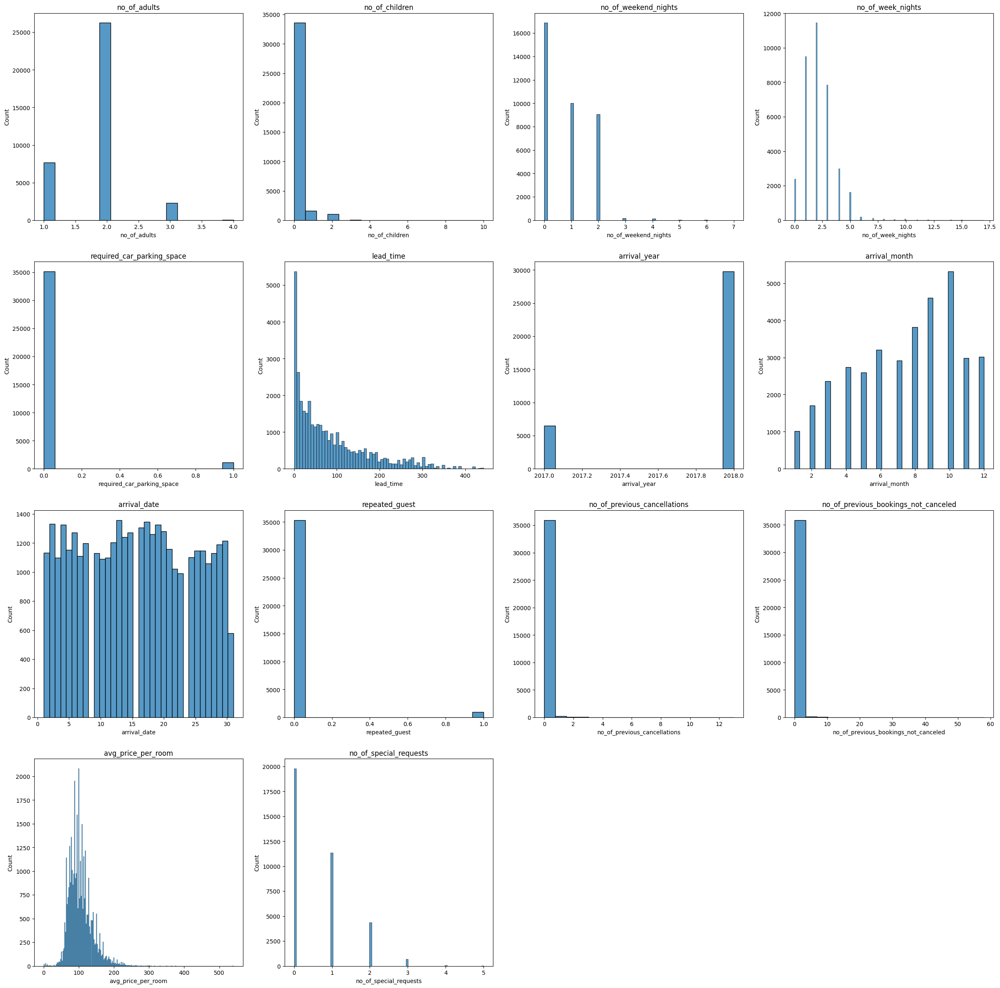

In [ ]:
# Let's quickly confirm that there are no missing values in the columns with numbers as well using histograms (since even though technically there aren't any missing values, entries might still have been registered as 0 when it is missing):

numeric_columns = ["no_of_adults", "no_of_children", "no_of_weekend_nights", "no_of_week_nights", "required_car_parking_space", "lead_time", "arrival_year", "arrival_month", "arrival_date", "repeated_guest", "no_of_previous_cancellations", "no_of_previous_bookings_not_canceled", "avg_price_per_room", "no_of_special_requests"]

plt.figure(figsize=(30,30))

for i, variable in enumerate(numeric_columns):
  plt.subplot(4, 4, i + 1)
  sns.histplot(dataset[variable])
  plt.tight_layout
  plt.title(variable)

plt.show()

- The variables of number of adults and average price per room having entries of 0 is a little suspicious. These might actually be missing values because it is doubtful the hotel group would allow minors to stay by themselves without the accompaniment of an adult, and the price per room being 0 implies it is free of cost, which is also unlikely.

- We will treat these entries by replacing the 0s with the median of the respective variables.

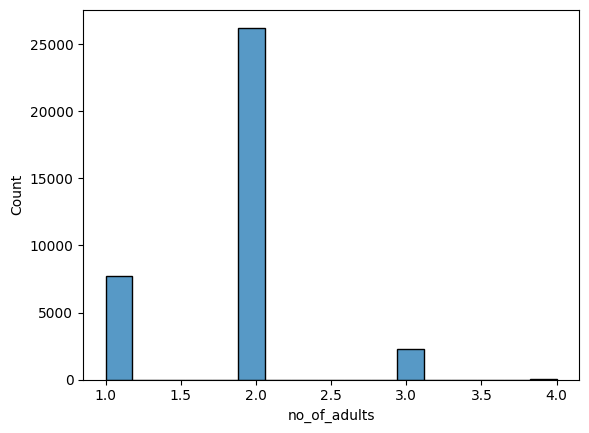

In [ ]:
# Replacing 0s in no_of_adults and avg_price_per_room with the medians of the respective variables:

dataset['no_of_adults'] = dataset['no_of_adults'].replace(0, dataset['no_of_adults'].median())
dataset['avg_price_per_room'] = dataset['avg_price_per_room'].replace(0, dataset['avg_price_per_room'].median())

# Great, now let's take a look at their distributions once more to ensure they've been replaced:

sns.histplot(dataset['no_of_adults'])

plt.show()

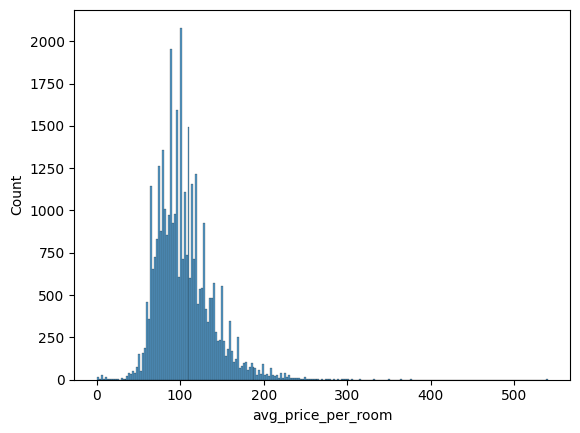

In [ ]:
sns.histplot(dataset['avg_price_per_room'])
plt.show()

- Great, now we can confirm that there are truly no missing values across our entire dataset.

In [ ]:
# Now, let's check to see if there are any duplicated observations on the dataset:

dataset.duplicated().sum()

np.int64(0)

- We can confirm there are no duplicated entries in the dataset as well.

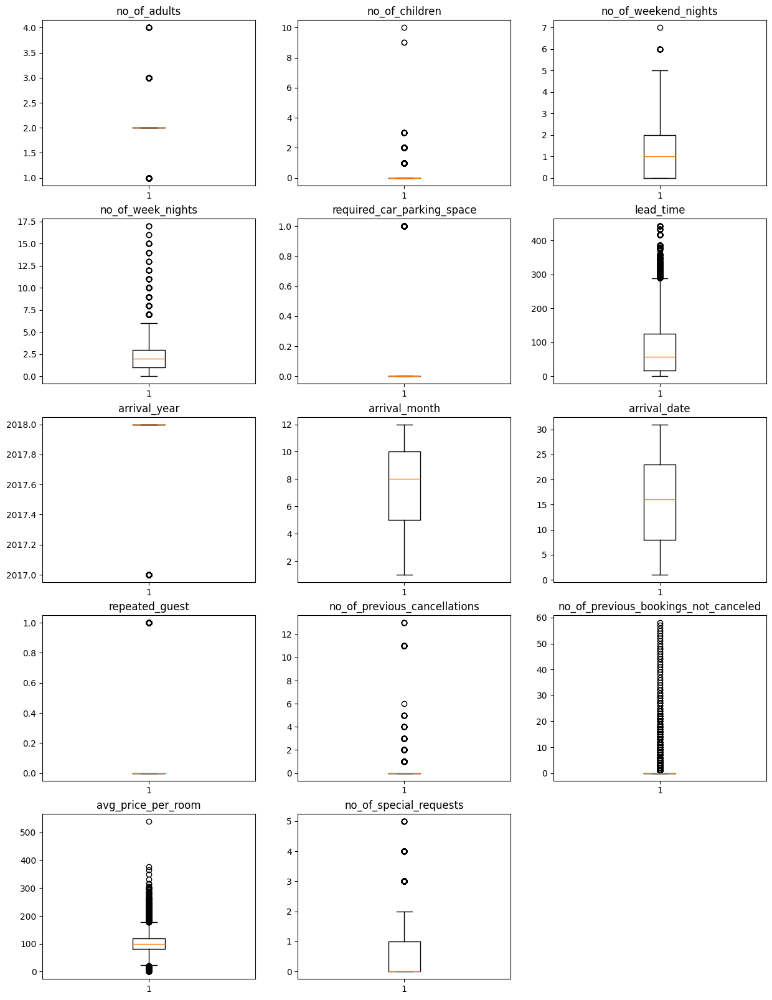

In [ ]:
# Now, let's check for problematic outliers:

plt.figure(figsize=(15,20))

for i, variable in enumerate(numeric_columns):
  plt.subplot(5, 3, i + 1)
  plt.boxplot(dataset[variable], whis = 1.5)
  plt.tight_layout
  plt.title(variable)

plt.show()

In [ ]:
dataset['repeated_guest'].value_counts()

,count
repeated_guest,
0,35345
1,930


In [ ]:
dataset['no_of_previous_cancellations'].value_counts()

,count
no_of_previous_cancellations,
0,35937
1,198
2,46
3,43
11,25
5,11
4,10
13,4
6,1


In [ ]:
dataset['no_of_special_requests'].value_counts()

,count
no_of_special_requests,
0,19777
1,11373
2,4364
3,675
4,78
5,8


- Let's start with number of adults and children, the maximum and minimum values suggest there is nothing odd here as there could be bookings made for one or more families coming to stay.

- Next, we look at the number of nights booked for on weekends and weekdays. While there are outliers, it is very possible that there are some people looking for an extended stay, one that is higher than typical. Same with lead time, it is imaginable that different people plan for their stays with different time frames. No issues here too.

- Next, we look at number of previous cancellations and number of previous bookings not cancelled. These depend on whether someone is a repeated guest to begin with, and it is understandble that the people who cancel are the outliers compared to people who don't since they ae also fewer in number (as seen in the value_counts function above). When we see previous bookings that haven't been cancelled, we notice a continuous stretch of outliers. This could simply be because the number of new guests are way more than repeated ones (as seen in the value_counts function above).

- Lastly, we see average price per room and number of special requests. The price per room is bound to fluctuate depending on several factors and it is understandable that the more extreme ones are the outliers as they're occurence is lesser. When it comes to special requests, it also makes sense that people who place such requests are significantly fewer than those who don't (as seen in the value_counts function above), and hence the outliers.

- We also have some variables where there are few or no outliers, such as the year, month and date of arrival. This suggests that arrivals have been consistent as a function of time.

- To conclude, there are no problematic outliers in the dataset. Variables either have no outliers at all, or the ones that exist are sensible and valid.

### **Data Preparation for Logistic Regression and Decision Tree Classification**

- We're going to prepare two datasets from our parent dataset, one for logistic regression and one for decision tree classification, as they each require a different approach to feature engineering.

In [ ]:
# Let's prepare for logistic regression first. We will apply the one-hot encoding method to convert all discrete string based variables into integers. We will also simultaneously drop one of those dummies due to colinearity.

one_hot_cols = ["type_of_meal_plan", "room_type_reserved", "market_segment_type"]

dataset_rg = pd.get_dummies (dataset, columns = one_hot_cols,  drop_first = True)

dataset_rg.head()


,Booking_ID,no_of_adults,no_of_children,no_of_weekend_nights,no_of_week_nights,required_car_parking_space,lead_time,arrival_year,arrival_month,arrival_date,...,room_type_reserved_Room_Type 2,room_type_reserved_Room_Type 3,room_type_reserved_Room_Type 4,room_type_reserved_Room_Type 5,room_type_reserved_Room_Type 6,room_type_reserved_Room_Type 7,market_segment_type_Complementary,market_segment_type_Corporate,market_segment_type_Offline,market_segment_type_Online
0,INN00001,2,0,1,2,0,224,2017,10,2,...,False,False,False,False,False,False,False,False,True,False
1,INN00002,2,0,2,3,0,5,2018,11,6,...,False,False,False,False,False,False,False,False,False,True
2,INN00003,1,0,2,1,0,1,2018,2,28,...,False,False,False,False,False,False,False,False,False,True
3,INN00004,2,0,0,2,0,211,2018,5,20,...,False,False,False,False,False,False,False,False,False,True
4,INN00005,2,0,1,1,0,48,2018,4,11,...,False,False,False,False,False,False,False,False,False,True


In [ ]:
#Let's check the info of the dataset:

dataset_rg.info()

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 36275 entries, 0 to 36274
Data columns (total 29 columns):
 #   Column                                Non-Null Count  Dtype  
---  ------                                --------------  -----  
 0   Booking_ID                            36275 non-null  object 
 1   no_of_adults                          36275 non-null  int64  
 2   no_of_children                        36275 non-null  int64  
 3   no_of_weekend_nights                  36275 non-null  int64  
 4   no_of_week_nights                     36275 non-null  int64  
 5   required_car_parking_space            36275 non-null  int64  
 6   lead_time                             36275 non-null  int64  
 7   arrival_year                          36275 non-null  int64  
 8   arrival_month                         36275 non-null  int64  
 9   arrival_date                          36275 non-null  int64  
 10  repeated_guest                        36275 non-null  int64  
 11  no_of_previous_

In [ ]:
# We see that our dummy columns contain boolean datatypes. Let's convert this to integers:

dataset_rg.iloc [:, 16:] = dataset_rg.iloc [:, 16:].astype(int)

dataset_rg.info()

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 36275 entries, 0 to 36274
Data columns (total 29 columns):
 #   Column                                Non-Null Count  Dtype  
---  ------                                --------------  -----  
 0   Booking_ID                            36275 non-null  object 
 1   no_of_adults                          36275 non-null  int64  
 2   no_of_children                        36275 non-null  int64  
 3   no_of_weekend_nights                  36275 non-null  int64  
 4   no_of_week_nights                     36275 non-null  int64  
 5   required_car_parking_space            36275 non-null  int64  
 6   lead_time                             36275 non-null  int64  
 7   arrival_year                          36275 non-null  int64  
 8   arrival_month                         36275 non-null  int64  
 9   arrival_date                          36275 non-null  int64  
 10  repeated_guest                        36275 non-null  int64  
 11  no_of_previous_

/tmp/ipykernel_274/1249311410.py:3: FutureWarning: Setting an item of incompatible dtype is deprecated and will raise in a future error of pandas. Value '0        0
1        0
2        0
3        0
4        0
        ..
36270    0
36271    0
36272    0
36273    0
36274    0
Name: type_of_meal_plan_Meal Plan 2, Length: 36275, dtype: int64' has dtype incompatible with bool, please explicitly cast to a compatible dtype first.
  dataset_rg.iloc [:, 16:] = dataset_rg.iloc [:, 16:].astype(int)
/tmp/ipykernel_274/1249311410.py:3: FutureWarning: Setting an item of incompatible dtype is deprecated and will raise in a future error of pandas. Value '0        0
1        0
2        0
3        0
4        0
        ..
36270    0
36271    0
36272    0
36273    0
36274    0
Name: type_of_meal_plan_Meal Plan 3, Length: 36275, dtype: int64' has dtype incompatible with bool, please explicitly cast to a compatible dtype first.
  dataset_rg.iloc [:, 16:] = dataset_rg.iloc [:, 16:].astype(int)
/tmp/ipykernel

In [ ]:
dataset_rg.head()

,Booking_ID,no_of_adults,no_of_children,no_of_weekend_nights,no_of_week_nights,required_car_parking_space,lead_time,arrival_year,arrival_month,arrival_date,...,room_type_reserved_Room_Type 2,room_type_reserved_Room_Type 3,room_type_reserved_Room_Type 4,room_type_reserved_Room_Type 5,room_type_reserved_Room_Type 6,room_type_reserved_Room_Type 7,market_segment_type_Complementary,market_segment_type_Corporate,market_segment_type_Offline,market_segment_type_Online
0,INN00001,2,0,1,2,0,224,2017,10,2,...,0,0,0,0,0,0,0,0,1,0
1,INN00002,2,0,2,3,0,5,2018,11,6,...,0,0,0,0,0,0,0,0,0,1
2,INN00003,1,0,2,1,0,1,2018,2,28,...,0,0,0,0,0,0,0,0,0,1
3,INN00004,2,0,0,2,0,211,2018,5,20,...,0,0,0,0,0,0,0,0,0,1
4,INN00005,2,0,1,1,0,48,2018,4,11,...,0,0,0,0,0,0,0,0,0,1


In [ ]:
# Before we proceed further, let's drop the "Booking_ID" column from our dataset for analysis since it is an assigned attribute.

dataset_rg = dataset_rg.drop ("Booking_ID", axis = 1)

dataset_rg.head()

,no_of_adults,no_of_children,no_of_weekend_nights,no_of_week_nights,required_car_parking_space,lead_time,arrival_year,arrival_month,arrival_date,repeated_guest,...,room_type_reserved_Room_Type 2,room_type_reserved_Room_Type 3,room_type_reserved_Room_Type 4,room_type_reserved_Room_Type 5,room_type_reserved_Room_Type 6,room_type_reserved_Room_Type 7,market_segment_type_Complementary,market_segment_type_Corporate,market_segment_type_Offline,market_segment_type_Online
0,2,0,1,2,0,224,2017,10,2,0,...,0,0,0,0,0,0,0,0,1,0
1,2,0,2,3,0,5,2018,11,6,0,...,0,0,0,0,0,0,0,0,0,1
2,1,0,2,1,0,1,2018,2,28,0,...,0,0,0,0,0,0,0,0,0,1
3,2,0,0,2,0,211,2018,5,20,0,...,0,0,0,0,0,0,0,0,0,1
4,2,0,1,1,0,48,2018,4,11,0,...,0,0,0,0,0,0,0,0,0,1


In [ ]:
# Great, let's now convert our dataset into two sets; one for training and one for testing our logistic regression model later on.

# First splitting dependent and independent variables and adding a constant to the independent variables:

y = dataset_rg["booking_status"]
x = dataset_rg.drop ("booking_status", axis = 1)
x = sm.add_constant (x)

# Next, splitting into training and testing sets:

x_train, x_test, y_train, y_test = train_test_split (x, y, test_size = 0.30, random_state = 1)

x_train.head()

,const,no_of_adults,no_of_children,no_of_weekend_nights,no_of_week_nights,required_car_parking_space,lead_time,arrival_year,arrival_month,arrival_date,...,room_type_reserved_Room_Type 2,room_type_reserved_Room_Type 3,room_type_reserved_Room_Type 4,room_type_reserved_Room_Type 5,room_type_reserved_Room_Type 6,room_type_reserved_Room_Type 7,market_segment_type_Complementary,market_segment_type_Corporate,market_segment_type_Offline,market_segment_type_Online
13662,1.0,1,0,0,1,0,163,2018,10,15,...,0,0,0,0,0,0,0,0,1,0
26641,1.0,2,0,0,3,0,113,2018,3,31,...,1,0,0,0,0,0,0,0,0,1
17835,1.0,2,0,2,3,0,359,2018,10,14,...,0,0,0,0,0,0,0,0,1,0
21485,1.0,2,0,0,3,0,136,2018,6,29,...,0,0,0,0,0,0,0,0,0,1
5670,1.0,2,0,1,2,0,21,2018,8,15,...,0,0,0,0,0,0,0,0,0,1


In [ ]:
y_train = y_train.map({"Not_Canceled": 0, "Canceled": 1})

y_train.head()

,booking_status
13662,1
26641,0
17835,0
21485,1
5670,1


In [ ]:
x_test.head()

,const,no_of_adults,no_of_children,no_of_weekend_nights,no_of_week_nights,required_car_parking_space,lead_time,arrival_year,arrival_month,arrival_date,...,room_type_reserved_Room_Type 2,room_type_reserved_Room_Type 3,room_type_reserved_Room_Type 4,room_type_reserved_Room_Type 5,room_type_reserved_Room_Type 6,room_type_reserved_Room_Type 7,market_segment_type_Complementary,market_segment_type_Corporate,market_segment_type_Offline,market_segment_type_Online
30392,1.0,1,0,1,0,0,53,2018,9,11,...,0,0,0,0,0,0,0,0,0,1
6685,1.0,2,0,1,2,0,63,2018,4,22,...,0,0,0,0,0,0,0,0,0,1
8369,1.0,2,0,2,3,0,55,2018,9,11,...,0,0,1,0,0,0,0,0,0,1
2055,1.0,2,0,0,2,0,53,2017,12,29,...,0,0,0,0,0,0,0,0,0,1
10969,1.0,1,0,2,4,0,245,2018,7,6,...,0,0,0,0,0,0,0,0,1,0


In [ ]:
y_test = y_test.map({"Not_Canceled": 0, "Canceled": 1})

y_test.head()

,booking_status
30392,0
6685,1
8369,0
2055,0
10969,1


In [ ]:
# Now let's move onto preparing a dataset for decision tree classification.

# Taking a look again at the head of the initial dataset:

dataset.head()

,Booking_ID,no_of_adults,no_of_children,no_of_weekend_nights,no_of_week_nights,type_of_meal_plan,required_car_parking_space,room_type_reserved,lead_time,arrival_year,arrival_month,arrival_date,market_segment_type,repeated_guest,no_of_previous_cancellations,no_of_previous_bookings_not_canceled,avg_price_per_room,no_of_special_requests,booking_status
0,INN00001,2,0,1,2,Meal Plan 1,0,Room_Type 1,224,2017,10,2,Offline,0,0,0,65.00,0,Not_Canceled
1,INN00002,2,0,2,3,Not Selected,0,Room_Type 1,5,2018,11,6,Online,0,0,0,106.68,1,Not_Canceled
2,INN00003,1,0,2,1,Meal Plan 1,0,Room_Type 1,1,2018,2,28,Online,0,0,0,60.00,0,Canceled
3,INN00004,2,0,0,2,Meal Plan 1,0,Room_Type 1,211,2018,5,20,Online,0,0,0,100.00,0,Canceled
4,INN00005,2,0,1,1,Not Selected,0,Room_Type 1,48,2018,4,11,Online,0,0,0,94.50,0,Canceled


- The variable of type of meal plan looks like it can be ordered since it ranges from no meals (not selected) to 3 meals a day (meal plan 3).

- Other than that, there is no reason to think any of the other variables with disrcete string elements are ordered in any way. Hence, we will apply one-hot encoding to all of them to create dummies from them.

- We will also remove the Booking ID column since it is an assigned attribute.

In [ ]:
# Starting by removing the "Booking_ID" column:

dataset_dt = dataset.drop ("Booking_ID", axis = 1)

In [ ]:
# Assigning ordered integers to the entries in the "type_of_meal_plan" column:

dataset_dt ["type_of_meal_plan"] = pd.Categorical (dataset_dt ["type_of_meal_plan"], categories = ["Not Selected", "Meal Plan 1", "Meal Plan 2", "Meal Plan 3"], ordered = True).codes

In [ ]:
# Applying one-hot encoding to get dummies from the remaining discrete string variable columns:

one_hot_cols = ["room_type_reserved", "market_segment_type"]

dataset_dt = pd.get_dummies (dataset_dt, columns = one_hot_cols,  drop_first = False) # We don't need to drop one of the dummy columns because decision trees are not impacted by multicolinearity.

dataset_dt.info()

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 36275 entries, 0 to 36274
Data columns (total 28 columns):
 #   Column                                Non-Null Count  Dtype  
---  ------                                --------------  -----  
 0   no_of_adults                          36275 non-null  int64  
 1   no_of_children                        36275 non-null  int64  
 2   no_of_weekend_nights                  36275 non-null  int64  
 3   no_of_week_nights                     36275 non-null  int64  
 4   type_of_meal_plan                     36275 non-null  int8   
 5   required_car_parking_space            36275 non-null  int64  
 6   lead_time                             36275 non-null  int64  
 7   arrival_year                          36275 non-null  int64  
 8   arrival_month                         36275 non-null  int64  
 9   arrival_date                          36275 non-null  int64  
 10  repeated_guest                        36275 non-null  int64  
 11  no_of_previous_

In [ ]:
# Let's convert the boolean datatype of the dummies to integers:

dataset_dt.iloc [:, 16:] = dataset_dt.iloc [:, 16:].astype(int)

dataset_dt.info()

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 36275 entries, 0 to 36274
Data columns (total 28 columns):
 #   Column                                Non-Null Count  Dtype  
---  ------                                --------------  -----  
 0   no_of_adults                          36275 non-null  int64  
 1   no_of_children                        36275 non-null  int64  
 2   no_of_weekend_nights                  36275 non-null  int64  
 3   no_of_week_nights                     36275 non-null  int64  
 4   type_of_meal_plan                     36275 non-null  int8   
 5   required_car_parking_space            36275 non-null  int64  
 6   lead_time                             36275 non-null  int64  
 7   arrival_year                          36275 non-null  int64  
 8   arrival_month                         36275 non-null  int64  
 9   arrival_date                          36275 non-null  int64  
 10  repeated_guest                        36275 non-null  int64  
 11  no_of_previous_

/tmp/ipykernel_274/3456719835.py:3: FutureWarning: Setting an item of incompatible dtype is deprecated and will raise in a future error of pandas. Value '0        1
1        1
2        1
3        1
4        1
        ..
36270    0
36271    1
36272    1
36273    1
36274    1
Name: room_type_reserved_Room_Type 1, Length: 36275, dtype: int64' has dtype incompatible with bool, please explicitly cast to a compatible dtype first.
  dataset_dt.iloc [:, 16:] = dataset_dt.iloc [:, 16:].astype(int)
/tmp/ipykernel_274/3456719835.py:3: FutureWarning: Setting an item of incompatible dtype is deprecated and will raise in a future error of pandas. Value '0        0
1        0
2        0
3        0
4        0
        ..
36270    0
36271    0
36272    0
36273    0
36274    0
Name: room_type_reserved_Room_Type 2, Length: 36275, dtype: int64' has dtype incompatible with bool, please explicitly cast to a compatible dtype first.
  dataset_dt.iloc [:, 16:] = dataset_dt.iloc [:, 16:].astype(int)
/tmp/ipykern

In [ ]:
# Now, let's split our dataset into training and testing datasets for decision tree classification:

y_dt = dataset_rg["booking_status"]
x_dt = dataset_rg.drop ("booking_status", axis = 1)

# Next, splitting into training and testing sets:

x_train_dt, x_test_dt, y_train_dt, y_test_dt = train_test_split (x_dt, y_dt, test_size = 0.30, random_state = 1)

x_train_dt.head()

,no_of_adults,no_of_children,no_of_weekend_nights,no_of_week_nights,required_car_parking_space,lead_time,arrival_year,arrival_month,arrival_date,repeated_guest,...,room_type_reserved_Room_Type 2,room_type_reserved_Room_Type 3,room_type_reserved_Room_Type 4,room_type_reserved_Room_Type 5,room_type_reserved_Room_Type 6,room_type_reserved_Room_Type 7,market_segment_type_Complementary,market_segment_type_Corporate,market_segment_type_Offline,market_segment_type_Online
13662,1,0,0,1,0,163,2018,10,15,0,...,0,0,0,0,0,0,0,0,1,0
26641,2,0,0,3,0,113,2018,3,31,0,...,1,0,0,0,0,0,0,0,0,1
17835,2,0,2,3,0,359,2018,10,14,0,...,0,0,0,0,0,0,0,0,1,0
21485,2,0,0,3,0,136,2018,6,29,0,...,0,0,0,0,0,0,0,0,0,1
5670,2,0,1,2,0,21,2018,8,15,0,...,0,0,0,0,0,0,0,0,0,1


In [ ]:
x_test_dt.head()

,no_of_adults,no_of_children,no_of_weekend_nights,no_of_week_nights,required_car_parking_space,lead_time,arrival_year,arrival_month,arrival_date,repeated_guest,...,room_type_reserved_Room_Type 2,room_type_reserved_Room_Type 3,room_type_reserved_Room_Type 4,room_type_reserved_Room_Type 5,room_type_reserved_Room_Type 6,room_type_reserved_Room_Type 7,market_segment_type_Complementary,market_segment_type_Corporate,market_segment_type_Offline,market_segment_type_Online
30392,1,0,1,0,0,53,2018,9,11,0,...,0,0,0,0,0,0,0,0,0,1
6685,2,0,1,2,0,63,2018,4,22,0,...,0,0,0,0,0,0,0,0,0,1
8369,2,0,2,3,0,55,2018,9,11,0,...,0,0,1,0,0,0,0,0,0,1
2055,2,0,0,2,0,53,2017,12,29,0,...,0,0,0,0,0,0,0,0,0,1
10969,1,0,2,4,0,245,2018,7,6,0,...,0,0,0,0,0,0,0,0,1,0


In [ ]:
y_train_dt = y_train_dt.map({"Not_Canceled": 0, "Canceled": 1})

y_train_dt.head()

,booking_status
13662,1
26641,0
17835,0
21485,1
5670,1


In [ ]:
y_test_dt = y_test_dt.map({"Not_Canceled": 0, "Canceled": 1})

y_test_dt.head()

,booking_status
30392,0
6685,1
8369,0
2055,0
10969,1


- Great, now our datasets for performing logistic regression and decision tree classification have been prepared.

## **Exploratory Data Analysis**

- Our problem at hand is customers cancelling on their bookings at the hotels where they plan to stay. We want to essentially understand the factors and attributes of customers that might correspond to such cancellations.

- We will do our exploratory data analysis keeping the above context and big picture in mind.

### **Univariate Analysis**

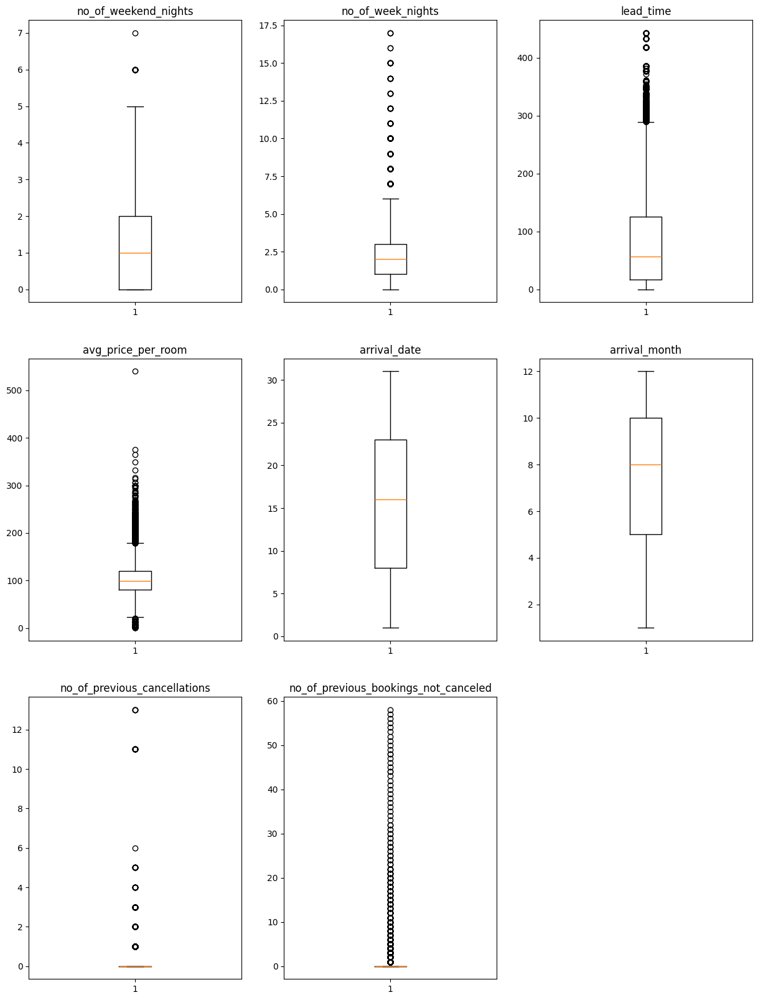

In [ ]:
# Let's start by looking at a boxplot of the continuous variables to get a sense for their distribution:

continuous_variables = ["no_of_weekend_nights", "no_of_week_nights", "lead_time", "avg_price_per_room", "arrival_date", "arrival_month", "no_of_previous_cancellations", "no_of_previous_bookings_not_canceled"]

plt.figure(figsize=(15,20))

for i, variable in enumerate(continuous_variables):
  plt.subplot(3, 3, i + 1)
  plt.boxplot(dataset[variable], whis = 1.5)
  plt.tight_layout
  plt.title(variable)

plt.show()

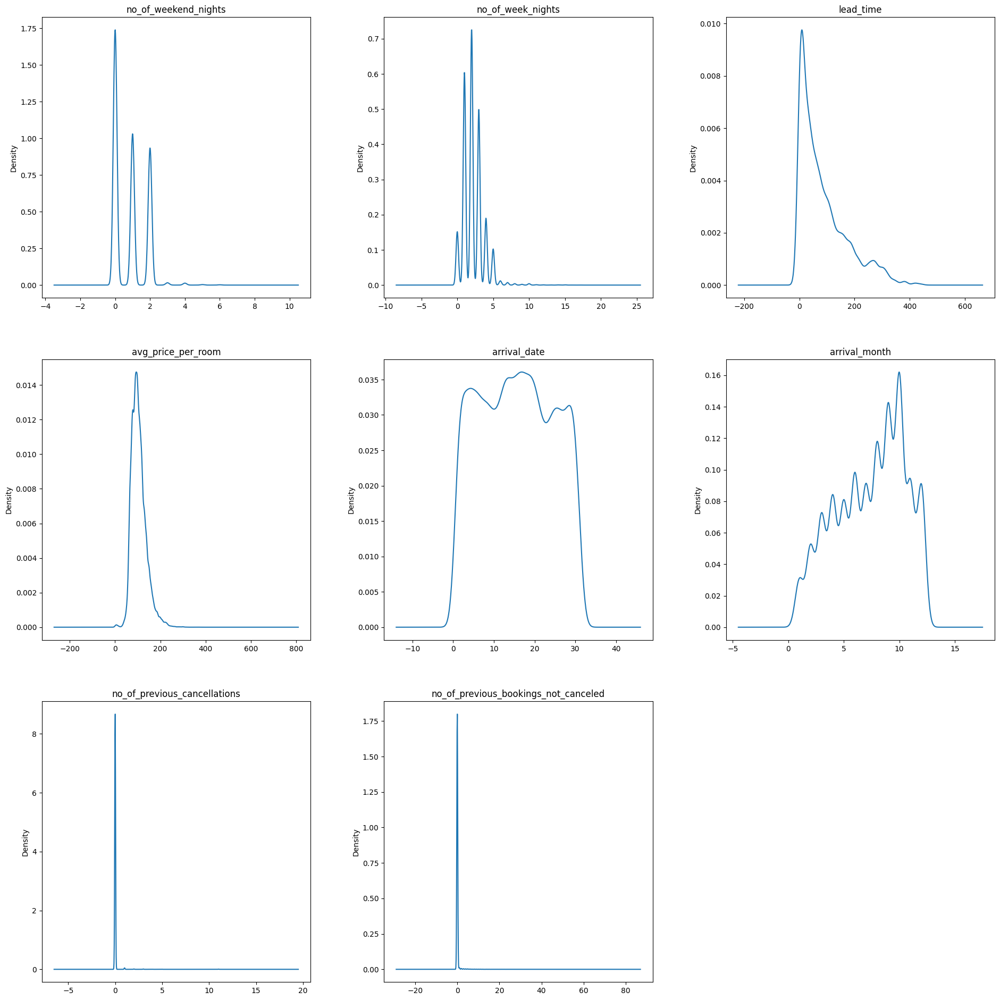

In [ ]:
# Next, we will look at their frequency distributions to get a different perspective:

plt.figure(figsize=(20,20))

for i, variable in enumerate(continuous_variables):
  plt.subplot(3, 3, i + 1)
  dataset[variable].plot(kind = "kde")
  plt.tight_layout (pad = 5)
  plt.title(variable)

plt.show()

- As we had already noted before in the data preprocessing stage, there are a few outliers in some variables as seen here in the boxplots. However, they are not problematic. The frequency distributions of these variables also reflect the same pattern.

In addition, some interesting observations:

- Number of weekend nights typically booked for extends till 2, and the number of weekday nights typically booked for extends till 5. These correspond to the period of one week since there are 5 weekdays and 2 days on the weekend. Hence, we see that customers typically make bookings for a period of less than a week.

- Number of bookings with lead time close to 0 are the highest and then it drops off with increasing time. This shows that last minute bookings are the highest by a significant margin.

- Average price per room falls within 200 Euros, and it is comparitively rare for the price to extend beyond this range.

- While there are minor dips, bookings are rather consistent throughout a month. Across months though, bookings are highest around October and lowest around December - January, with a rather steady rise and drop connecting them (the drop is a little on the steeper side). This might go to show when people prefer to go on vacation the most, possibly due in part to the climate and season.

- While cancellations are the focus of our problem, we still see that the vast majority of customers that have made previous bookings haven't cancelled.

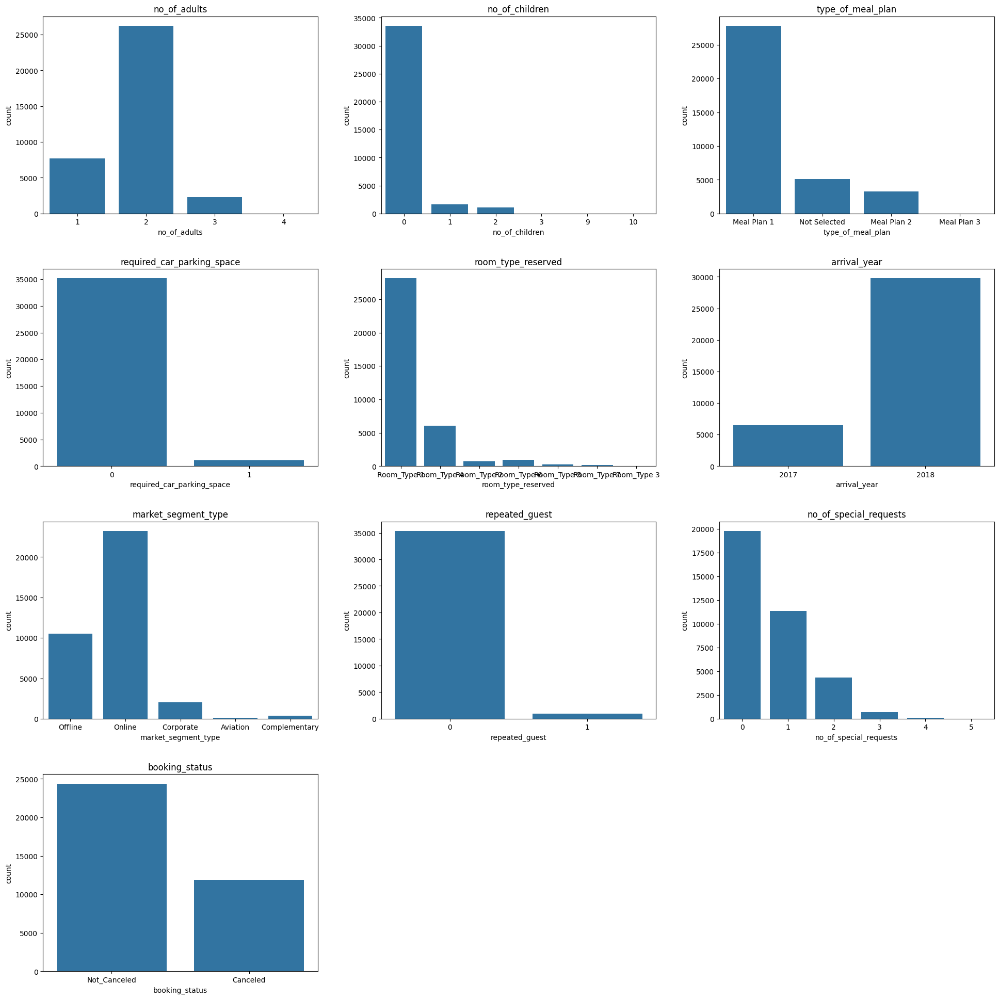

In [ ]:
# Now, let's look at the distributions of our discrete variables:

discrete_variables = ["no_of_adults", "no_of_children", "type_of_meal_plan", "required_car_parking_space", "room_type_reserved", "arrival_year", "market_segment_type", "repeated_guest", "no_of_special_requests", "booking_status"]

plt.figure(figsize=(20,20))

for i, variable in enumerate(discrete_variables):
  plt.subplot(4, 3, i + 1)
  sns.countplot(data = dataset, x = dataset[variable])
  plt.tight_layout (pad = 3)
  plt.title(variable)

plt.show()

- Bookings with 2 adults are 0 children are the most, suggesting the majority of customers might be couples with no kids.

- Meal Plan 1 is the most opted for meal plan. This might be because customers prefer to have only breakfast at the hotel and then spend the day out exploring.

- Most people also require no car parking space, suggesting that either they're travelling from far or that they've taken modes of transport to the location other than by car on road.

- Room type 1 is the most popular, bookings have gone up significantly in 2018 as compared to 2017, mojority of bookings happen online, vast majority of guests are first-time visitors, and the number of people with special requests drop with increasing number of requests.

- Most importantly, the number of bookings that were not cancelled are higher than those that were, which is a positive thing. However, we would ideally want to reduce the cancellations even further.

### **Bivariate Analysis**

<Figure size 2000x2000 with 0 Axes>

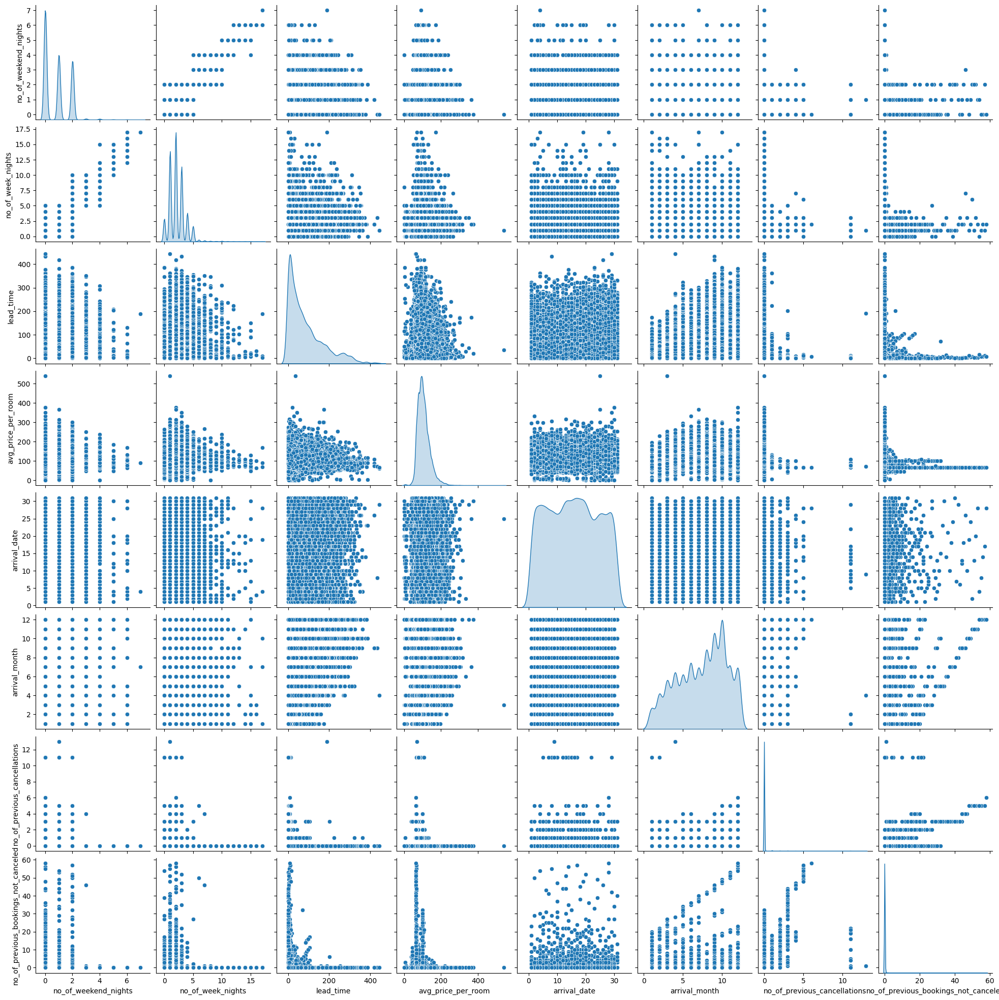

In [ ]:
# Let's start with looking at the continuous variables against one another:

plt.figure(figsize=(20,20))
sns.pairplot (dataset [continuous_variables], diag_kind="kde")
plt.show()

- Number of weekend nights booked for has no discernable patterns with any other variable except for number of weekday nights booked for. As the first goes up, so does the second. This is understandable since it might just reflect longer periods of stay. Same goes for the variable of number of weekday nights booked for as well.

- The patterns that the variable of lead time have with the rest reflects the distribution of the variable itself, and nothing calls for attention beyond that. Same goes for the variables of average price per room, and arrival date, number of previous cancellations, and number of previous bookings not cancelled.

- With arrival month, we see a couple of interesting things happening. Firstly, the number of previous bookings not cancelled tends to reach higher numbers the later into the year it is. This might mean that repeated guests who plan for vacations towards the end of the year are more likely to go through with their plans. Secondly, lead time for booking tends to grow from the beginning of the year and peak around October, suggesting people might plan for their stays increasingly earlier as their planned stay happens later in the year. Lastly, average price per room follows somewhat of a wave against different times of the year, peaking somewhere in the middle months, possibly reflecting demand.

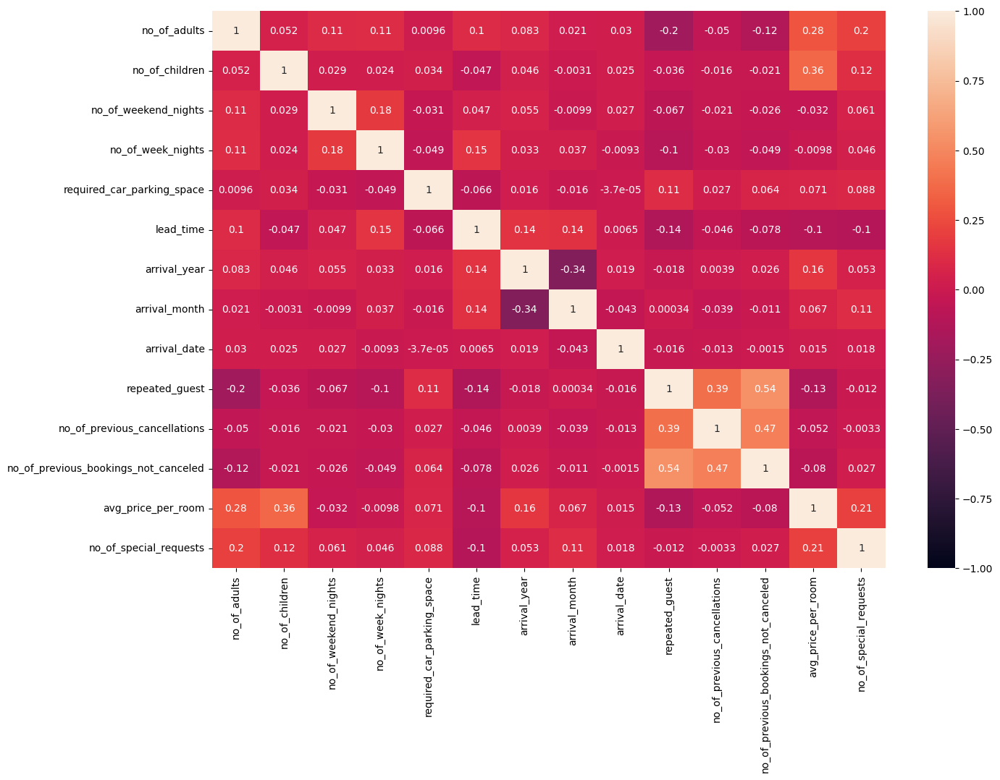

In [ ]:
# Let's now look at a correlation matrix of all numeric variables:

num_data = dataset.select_dtypes(include=['number'])

plt.figure(figsize=(15,10))
sns.heatmap(num_data.corr(), annot=True, vmin=-1, vmax=1)
plt.show()

- As we can see from the heatmap of the correlation matrix, the correlations are really low across the board which is good.

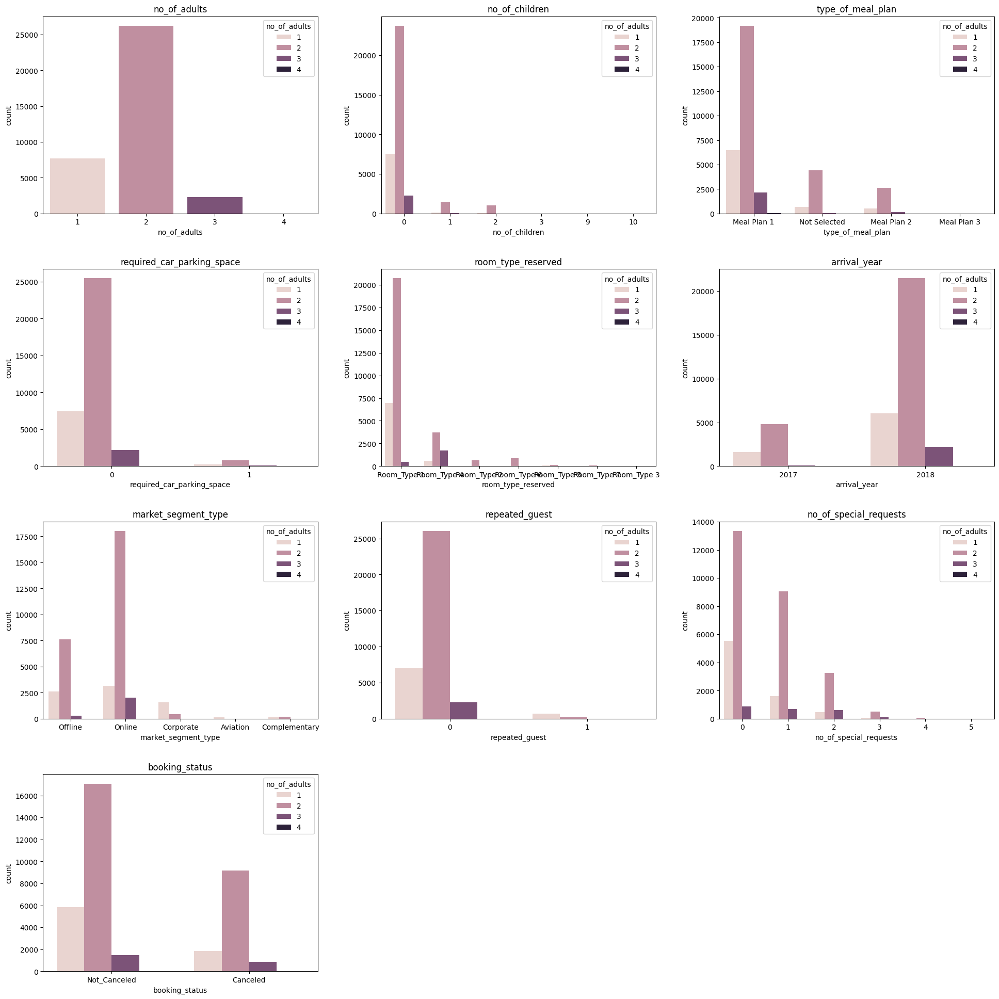

In [ ]:
# Next let's look at discrete variables against one another:

plt.figure(figsize=(20,20))

for i, variable in enumerate(discrete_variables):
  plt.subplot(4, 3, i + 1)
  sns.countplot(data = dataset, x = dataset[variable], hue = "no_of_adults")
  plt.tight_layout (pad = 3)
  plt.title(variable)

plt.show()

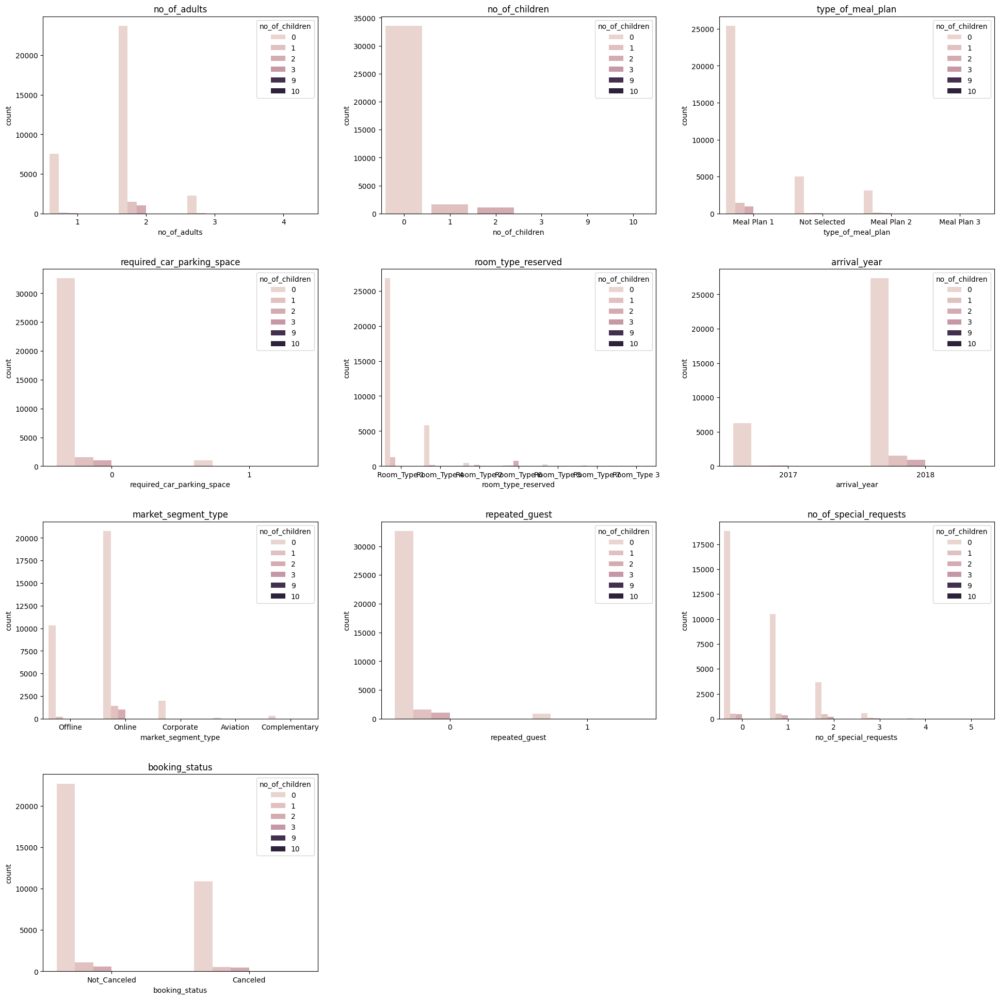

In [ ]:
plt.figure(figsize=(20,20))

for i, variable in enumerate(discrete_variables):
  plt.subplot(4, 3, i + 1)
  sns.countplot(data = dataset, x = dataset[variable], hue = "no_of_children")
  plt.tight_layout (pad = 3)
  plt.title(variable)

plt.show()

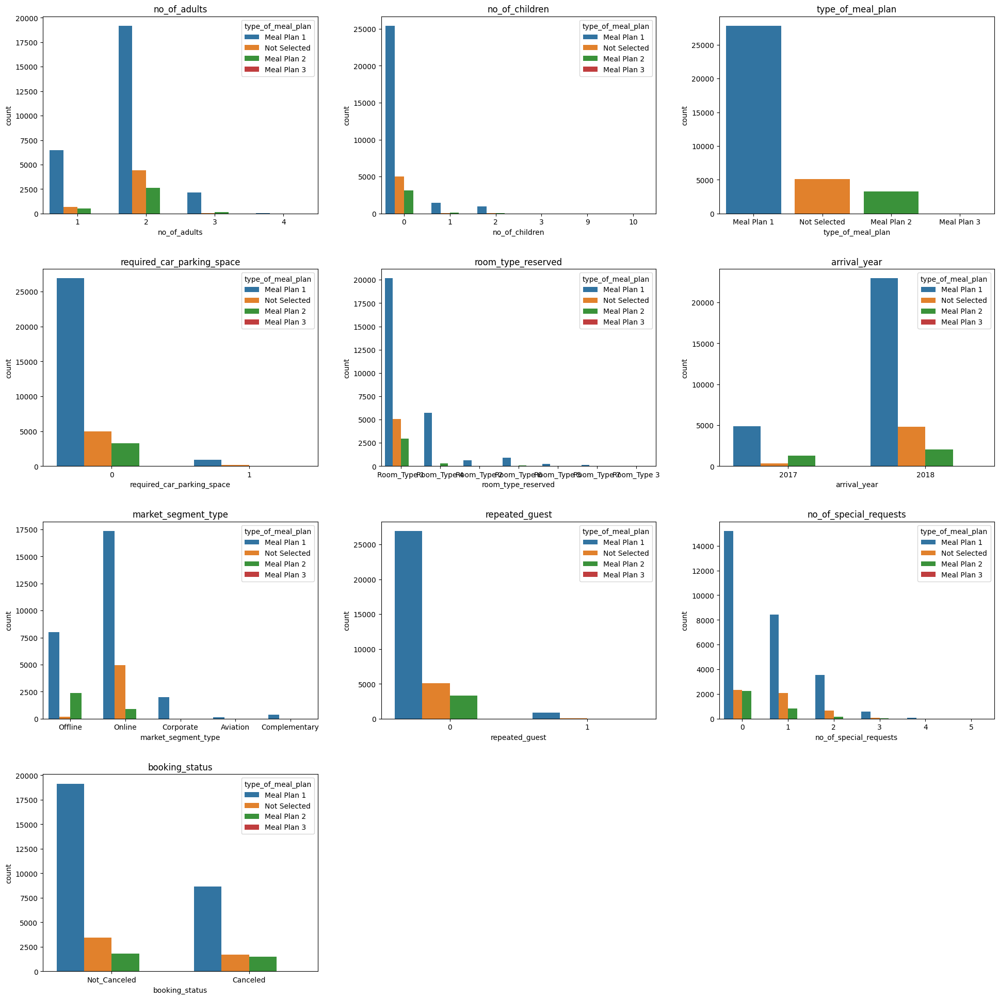

In [ ]:
plt.figure(figsize=(20,20))

for i, variable in enumerate(discrete_variables):
  plt.subplot(4, 3, i + 1)
  sns.countplot(data = dataset, x = dataset[variable], hue = "type_of_meal_plan")
  plt.tight_layout (pad = 3)
  plt.title(variable)

plt.show()

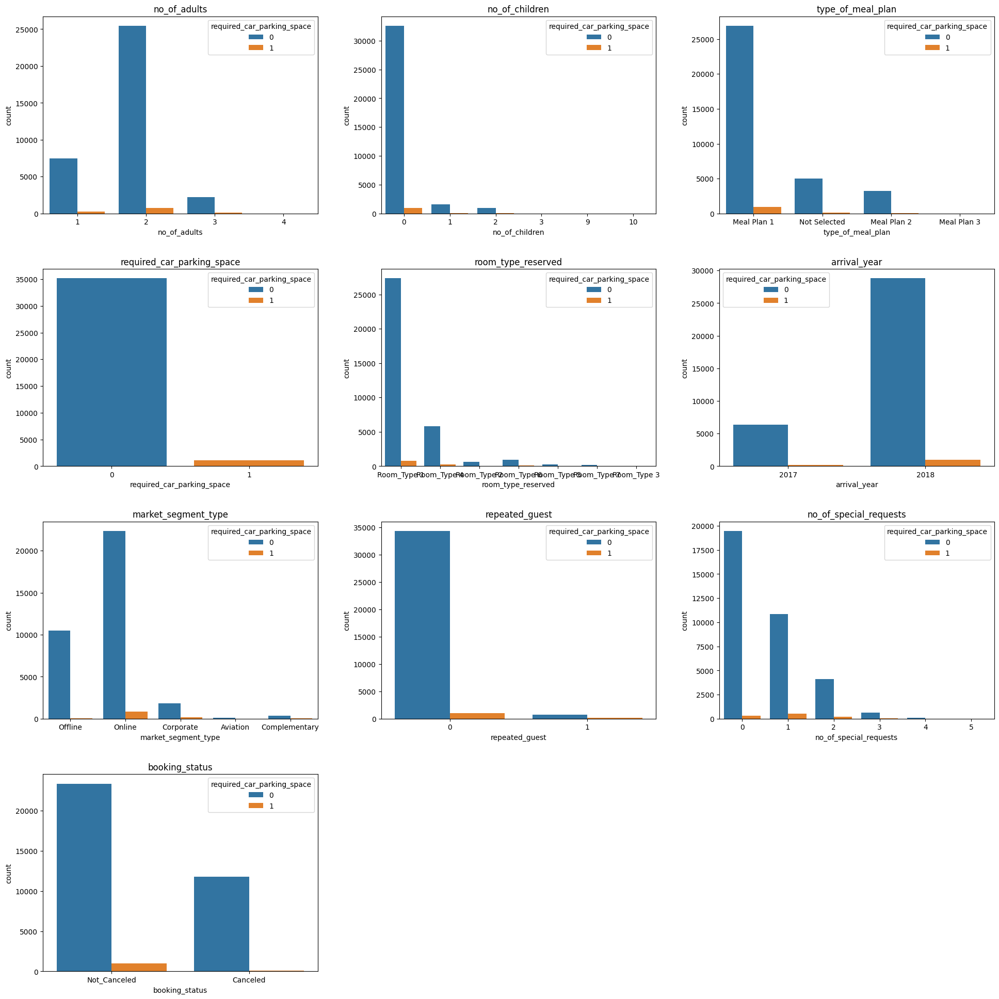

In [ ]:
plt.figure(figsize=(20,20))

for i, variable in enumerate(discrete_variables):
  plt.subplot(4, 3, i + 1)
  sns.countplot(data = dataset, x = dataset[variable], hue = "required_car_parking_space")
  plt.tight_layout (pad = 3)
  plt.title(variable)

plt.show()

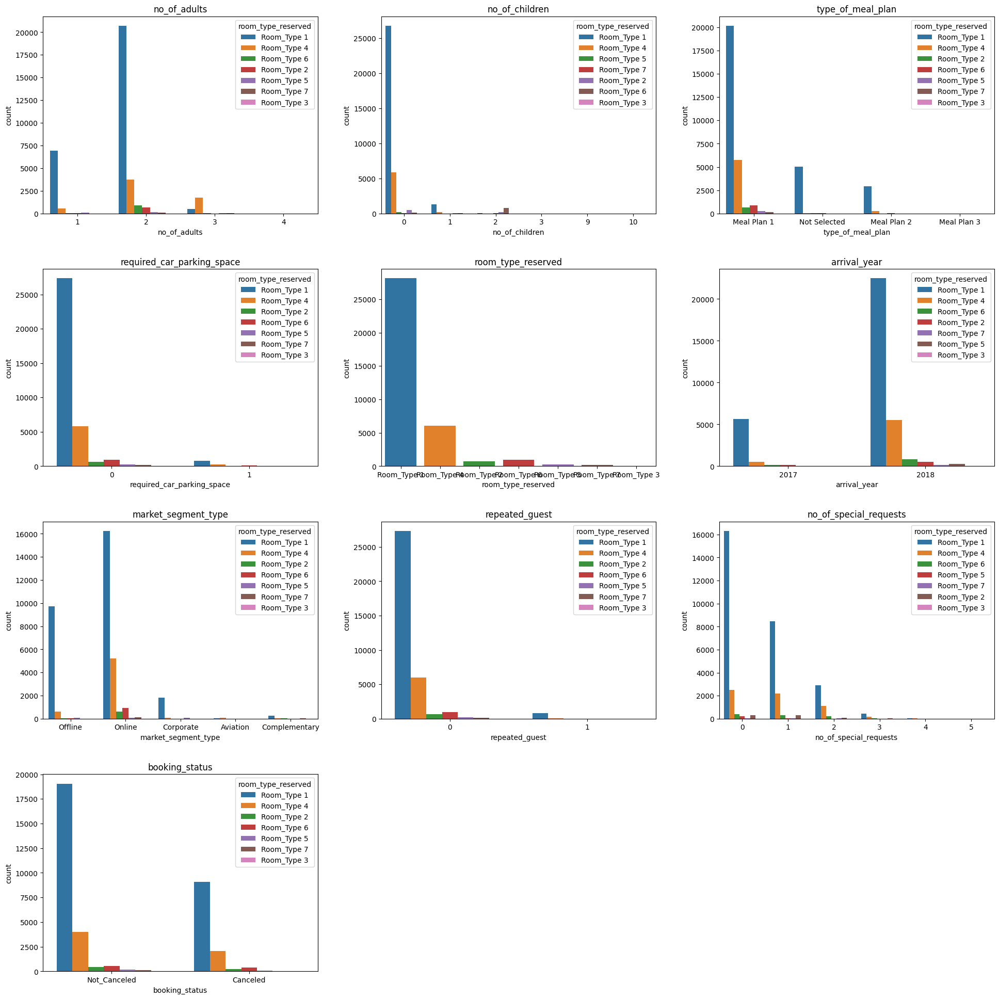

In [ ]:
plt.figure(figsize=(20,20))

for i, variable in enumerate(discrete_variables):
  plt.subplot(4, 3, i + 1)
  sns.countplot(data = dataset, x = dataset[variable], hue = "room_type_reserved")
  plt.tight_layout (pad = 3)
  plt.title(variable)

plt.show()

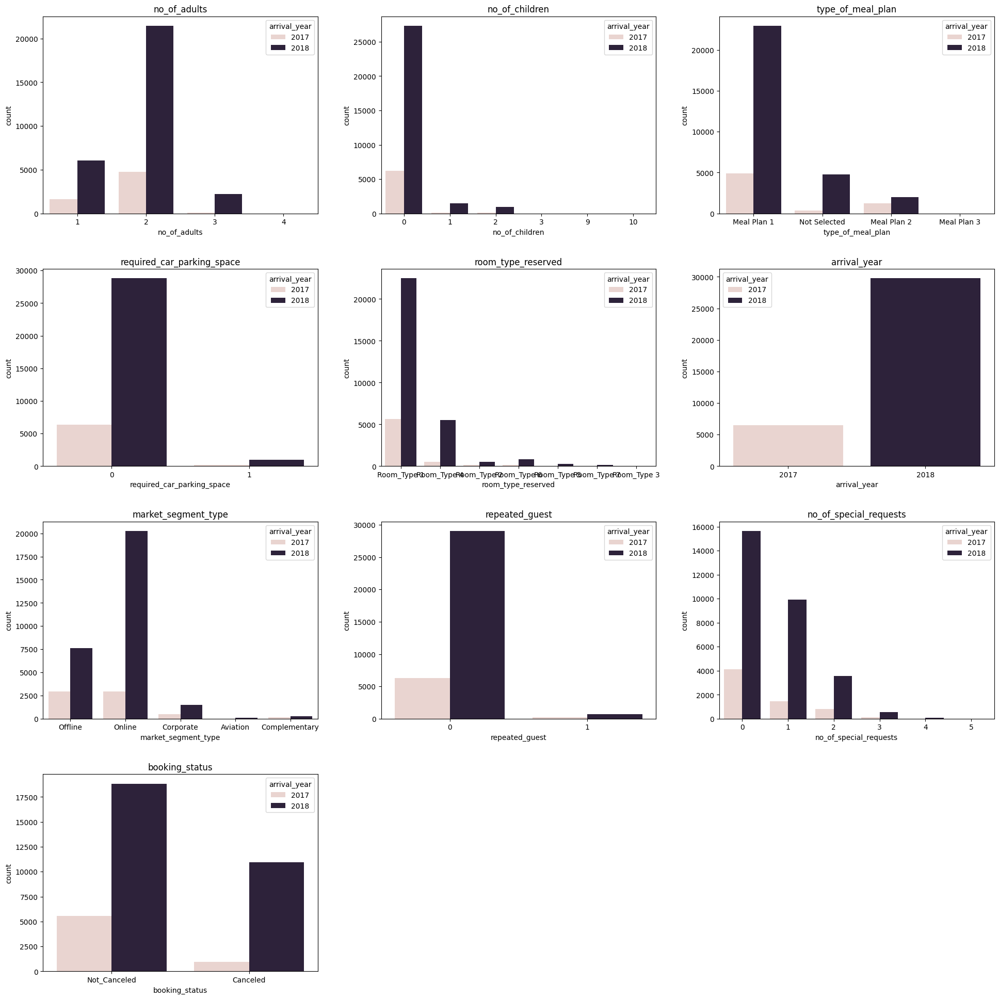

In [ ]:
plt.figure(figsize=(20,20))

for i, variable in enumerate(discrete_variables):
  plt.subplot(4, 3, i + 1)
  sns.countplot(data = dataset, x = dataset[variable], hue = "arrival_year")
  plt.tight_layout (pad = 3)
  plt.title(variable)

plt.show()

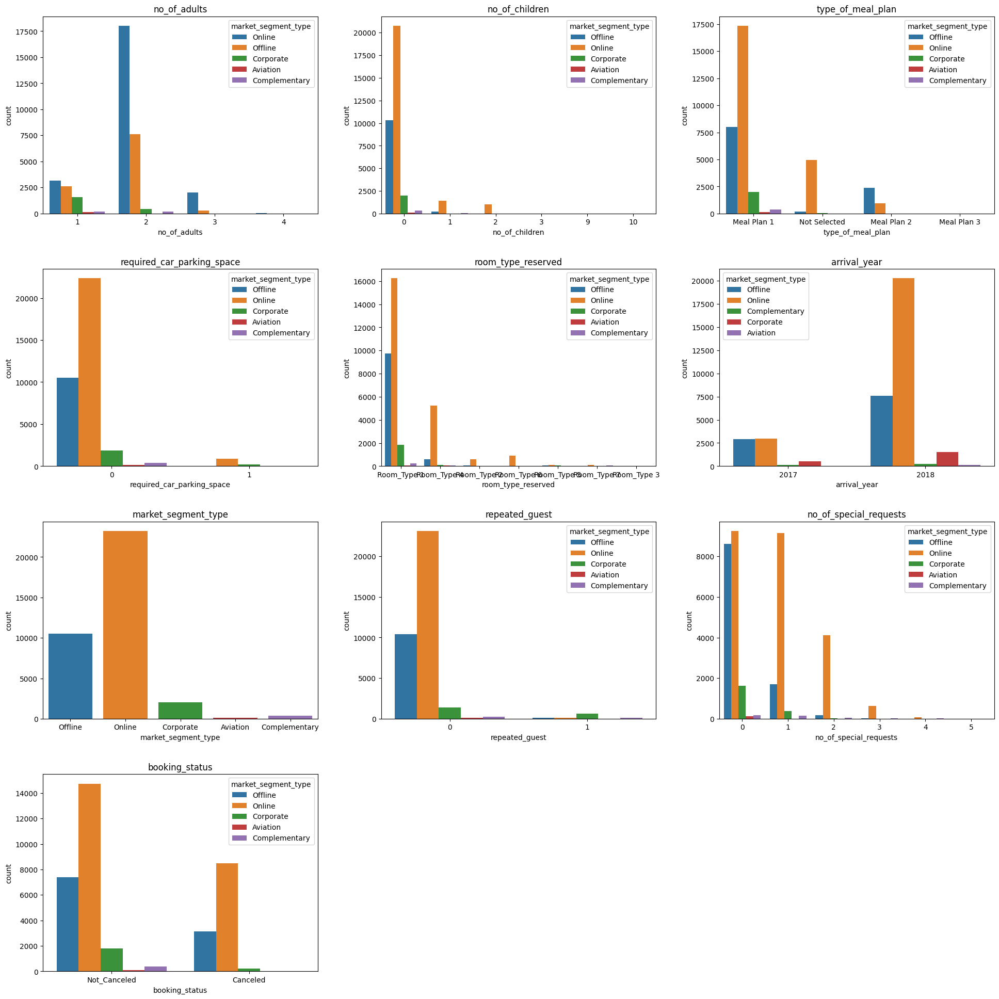

In [ ]:
plt.figure(figsize=(20,20))

for i, variable in enumerate(discrete_variables):
  plt.subplot(4, 3, i + 1)
  sns.countplot(data = dataset, x = dataset[variable], hue = "market_segment_type")
  plt.tight_layout (pad = 3)
  plt.title(variable)

plt.show()

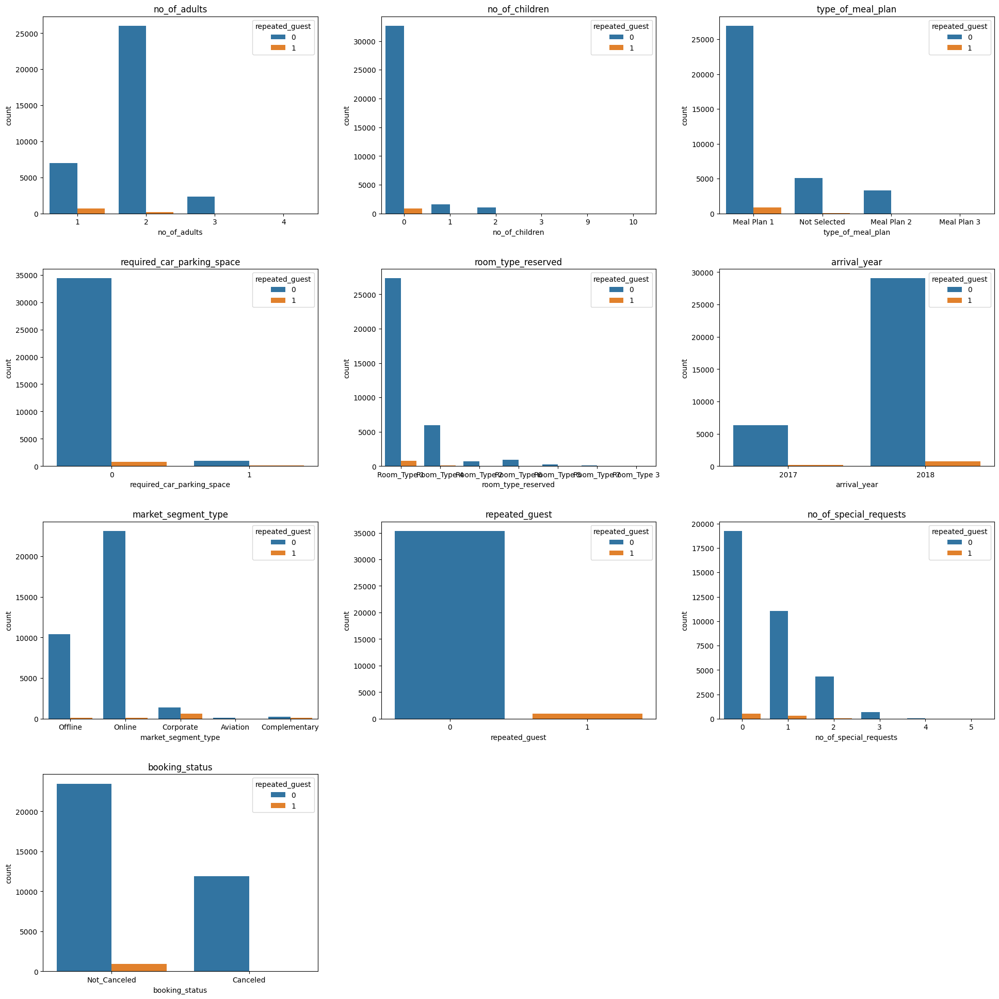

In [ ]:
plt.figure(figsize=(20,20))

for i, variable in enumerate(discrete_variables):
  plt.subplot(4, 3, i + 1)
  sns.countplot(data = dataset, x = dataset[variable], hue = "repeated_guest")
  plt.tight_layout (pad = 3)
  plt.title(variable)

plt.show()

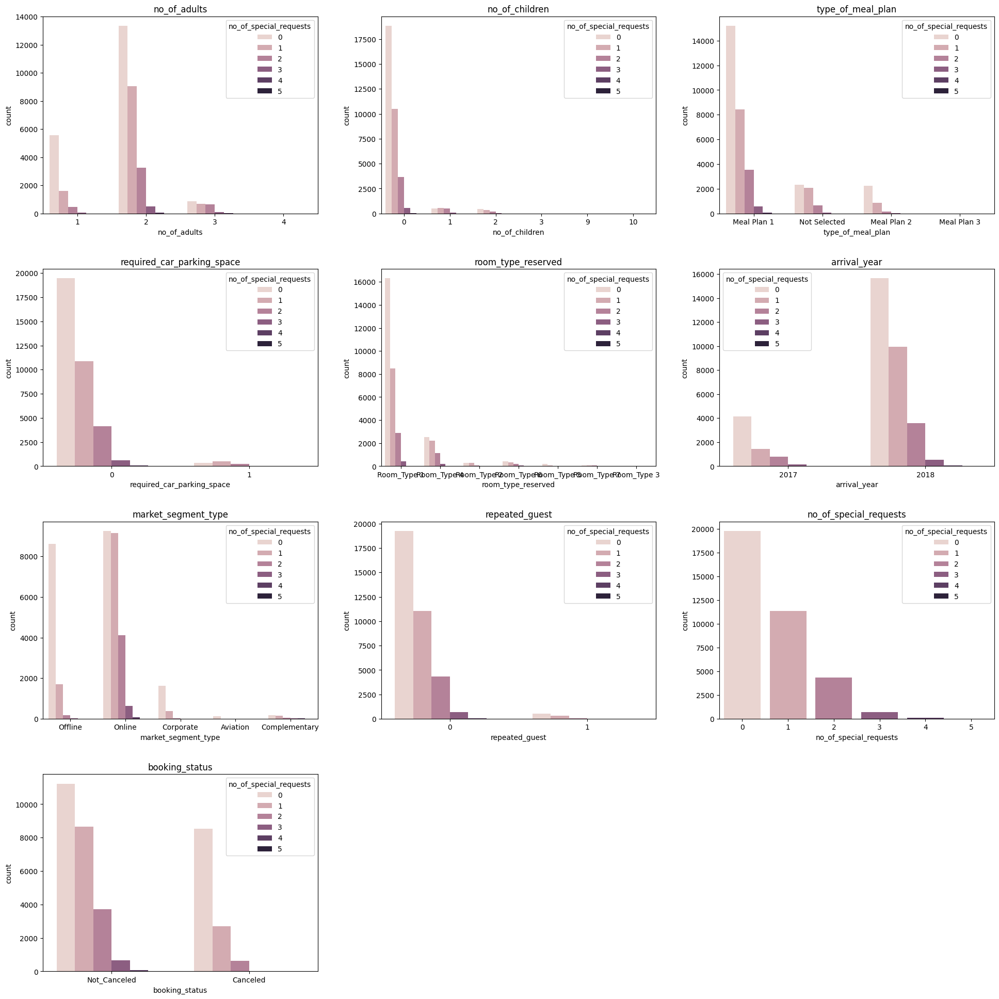

In [ ]:
plt.figure(figsize=(20,20))

for i, variable in enumerate(discrete_variables):
  plt.subplot(4, 3, i + 1)
  sns.countplot(data = dataset, x = dataset[variable], hue = "no_of_special_requests")
  plt.tight_layout (pad = 3)
  plt.title(variable)

plt.show()

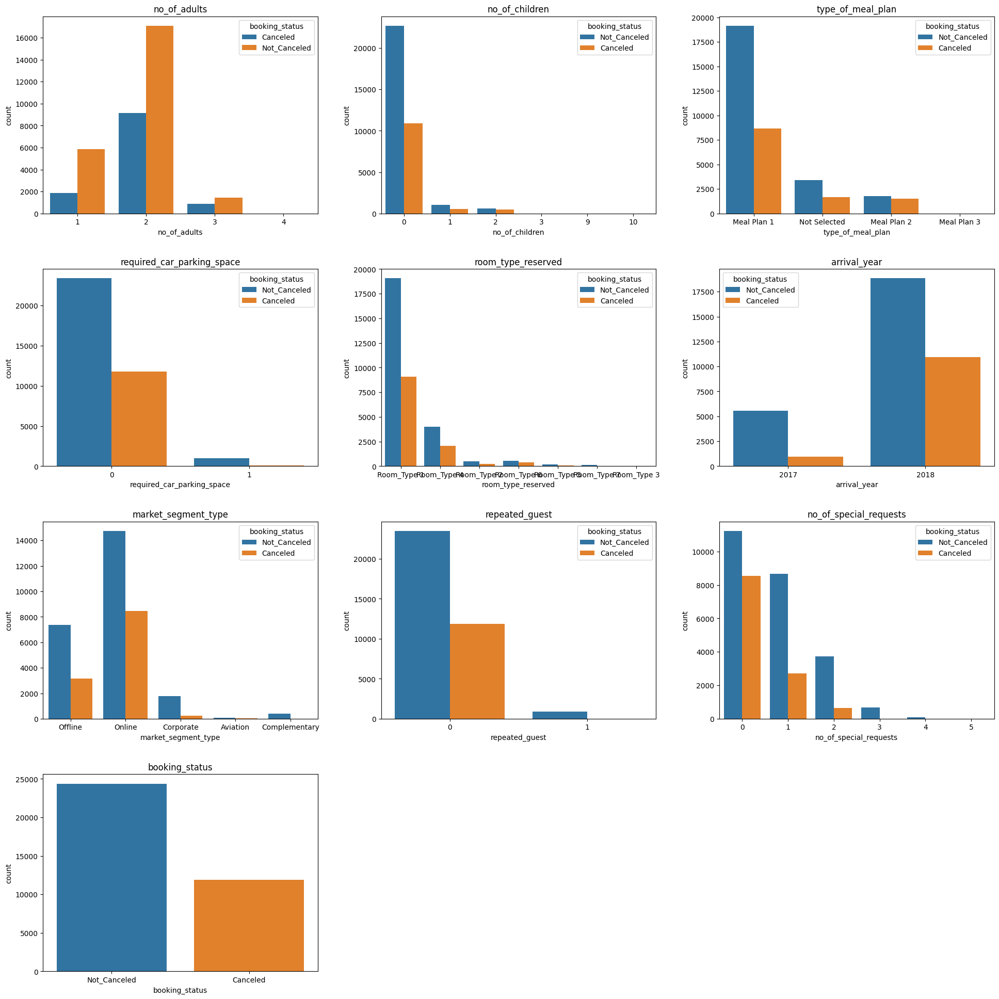

In [ ]:
plt.figure(figsize=(20,20))

for i, variable in enumerate(discrete_variables):
  plt.subplot(4, 3, i + 1)
  sns.countplot(data = dataset, x = dataset[variable], hue = "booking_status")
  plt.tight_layout (pad = 3)
  plt.title(variable)

plt.show()

- None of the discrete variables have a discernable pattern against the number of adults booked for. Same goes for the variables of number of children, required car parking space, room type reserved, arrival year, repeated guest, and most importantly, booking status.

- There is one interesting observation when it comes to the variable of type of meal plan selected. People who selected Meal Plan 2 are more likely to come from the market segment type of offline bookings as compared to online, despite the fact that online bookings are significantly more in number in general. Also, people who did not select a meal plan are reasonably fewer in the offline mode of booking than we might expect in comparison to the online mode. This might suggest older couples and a higher degree of indecision when booking online.

- The variable of market segment type has some interesting patterns with a few other variables. Starting with number of adults, we see that while online bookings are still the highest with bookings for 1 adult, the difference between online, offline and corporate bookings isn't as great as it is in the overall distribution. This suggests the bookings for a single adult happen approximately evenly across different market segments. Secondly, we see a similar pattern in arrival year: 2017 saw bookings rather evenly spread across online and offling segments, while the difference reflected in the overall distribution only becomes apparent in 2018. Lastly, we see that the vast majority of bookings through offline means have no special requests at all. Special requests overwhelmingly come mostly from online bookings. This might be because of available options online to do so, or it might be a reflection of customer attitudes.

- When we look at the variable of number of special requests, we see that within customers who made bookings online, the number of people who had a special request is almost the same as the number of people who had no requests, despite the overall distribution having a far greater number of no requests at all as compared to the rest. This points to the fact that people who make online bookings are far more likely to need customised accomodations.

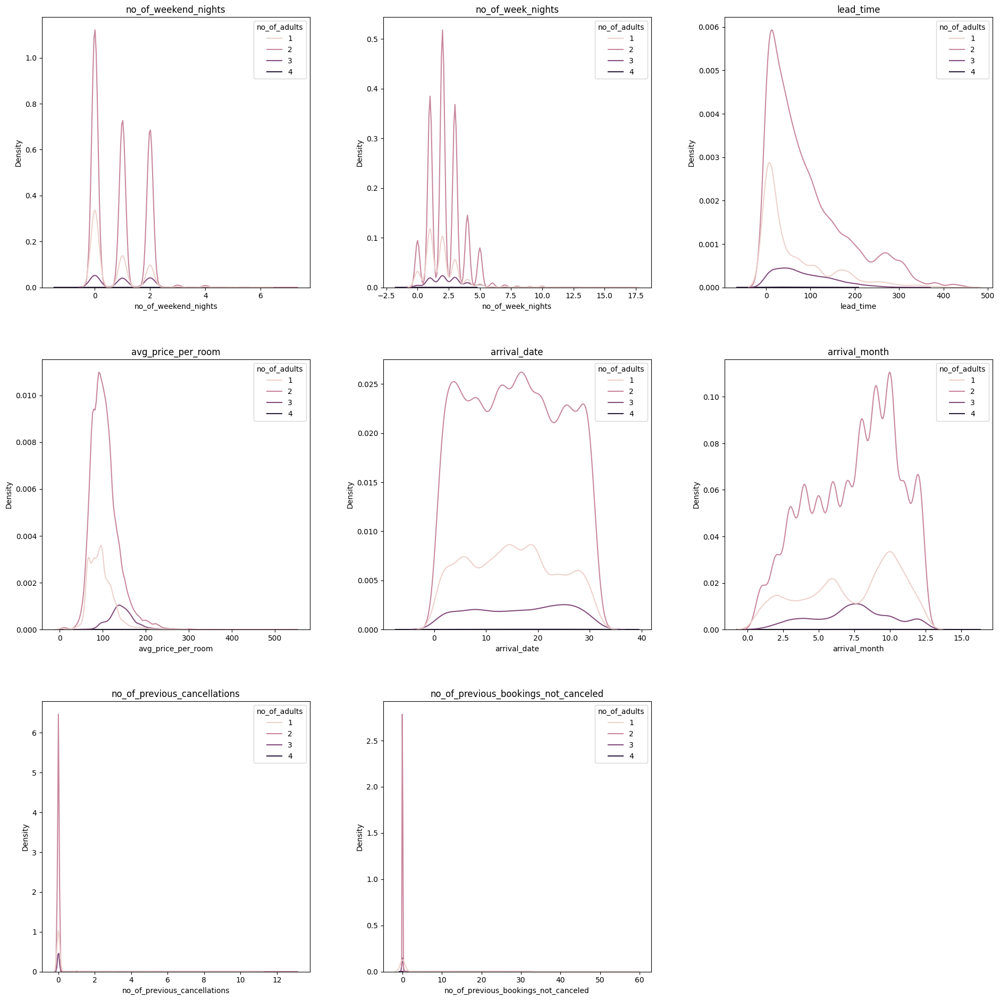

In [ ]:
# Lastly, let's look at continuous variables against discrete variables:

plt.figure(figsize=(20,20))

for i, variable in enumerate(continuous_variables):
  plt.subplot(3, 3, i + 1)
  sns.kdeplot(data = dataset, x = dataset[variable], hue = "no_of_adults", fill = False, warn_singular= False)
  plt.tight_layout (pad = 5)
  plt.title(variable)

plt.show()

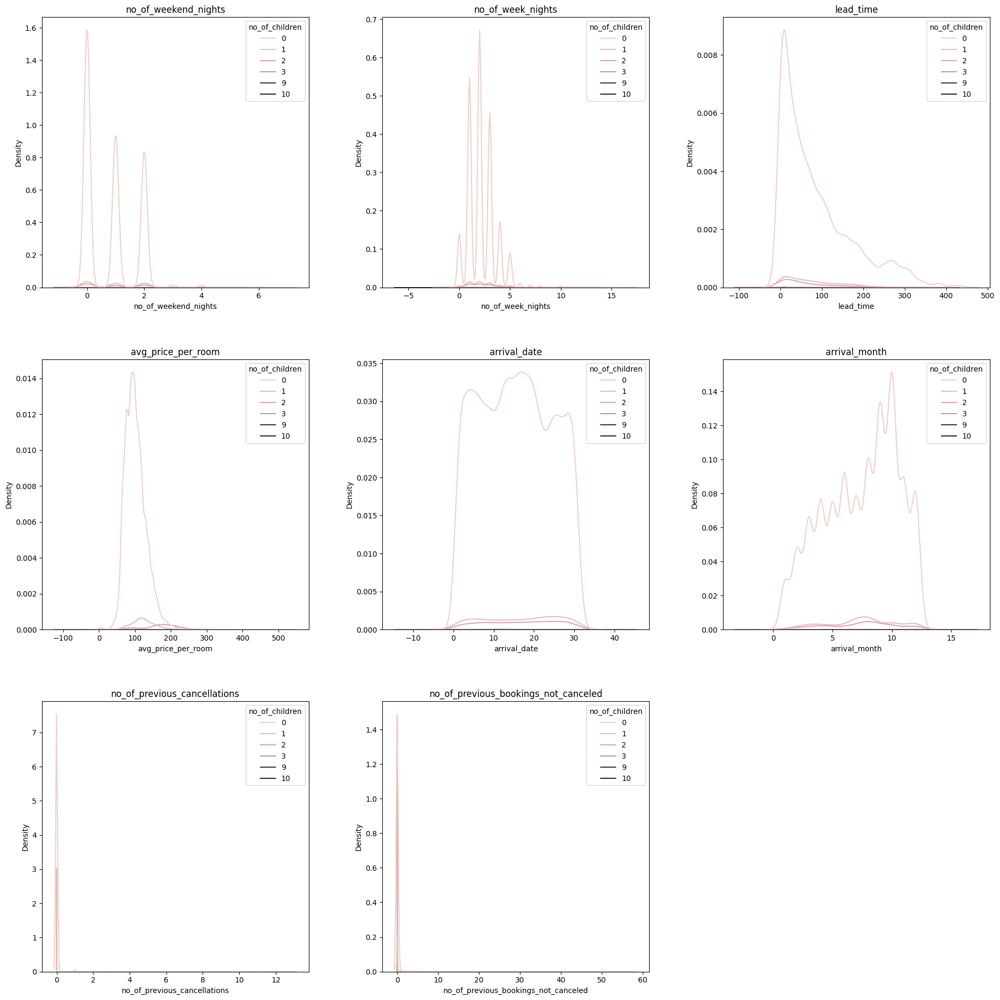

In [ ]:
plt.figure(figsize=(20,20))

for i, variable in enumerate(continuous_variables):
  plt.subplot(3, 3, i + 1)
  sns.kdeplot(data = dataset, x = dataset[variable], hue = "no_of_children", fill = False, warn_singular= False)
  plt.tight_layout (pad = 5)
  plt.title(variable)

plt.show()

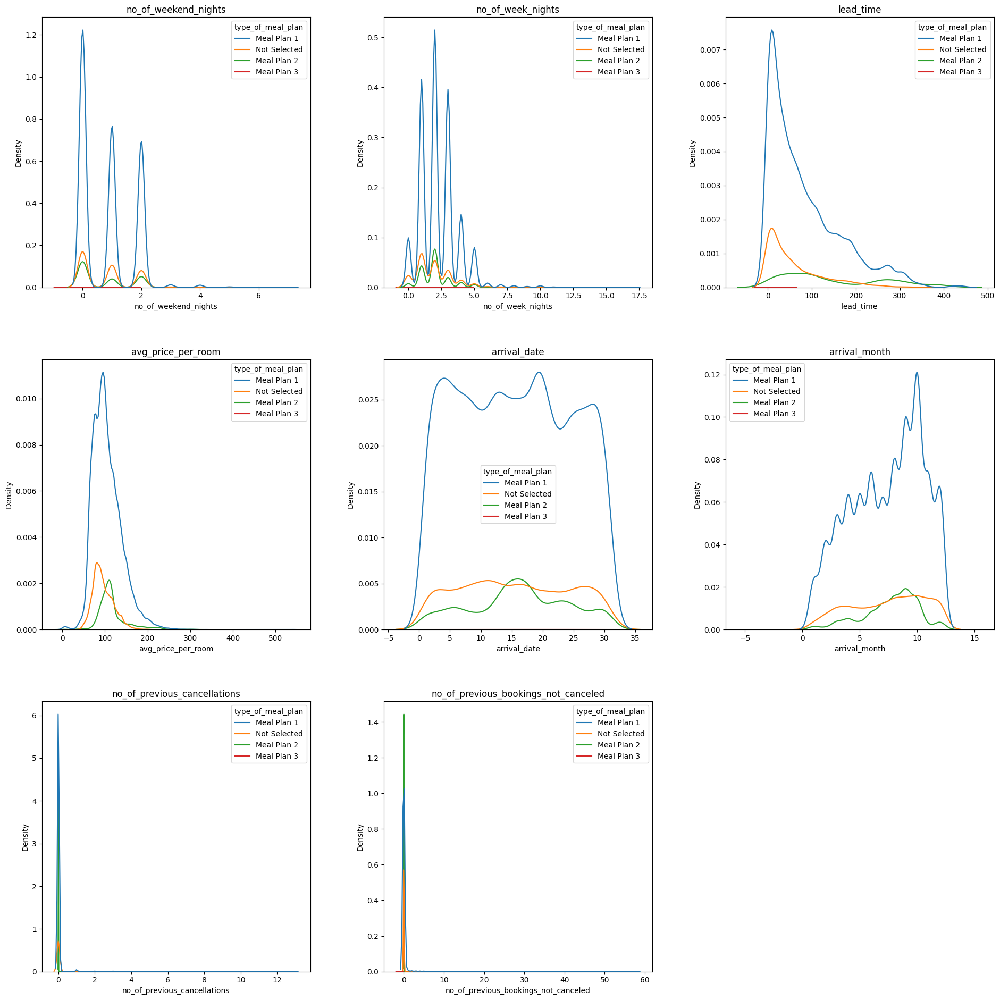

In [ ]:
plt.figure(figsize=(20,20))

for i, variable in enumerate(continuous_variables):
  plt.subplot(3, 3, i + 1)
  sns.kdeplot(data = dataset, x = dataset[variable], hue = "type_of_meal_plan", fill = False, warn_singular= False)
  plt.tight_layout (pad = 5)
  plt.title(variable)

plt.show()

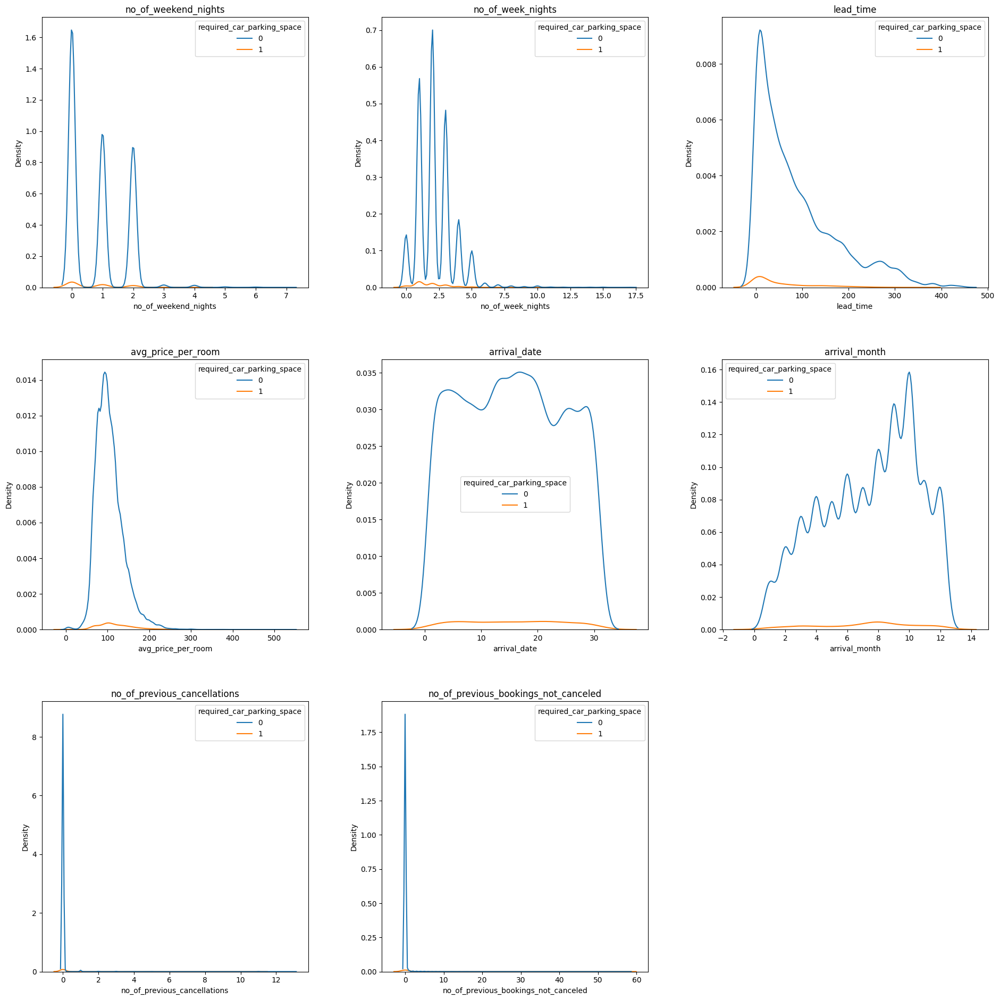

In [ ]:
plt.figure(figsize=(20,20))

for i, variable in enumerate(continuous_variables):
  plt.subplot(3, 3, i + 1)
  sns.kdeplot(data = dataset, x = dataset[variable], hue = "required_car_parking_space", fill = False, warn_singular= False)
  plt.tight_layout (pad = 5)
  plt.title(variable)

plt.show()

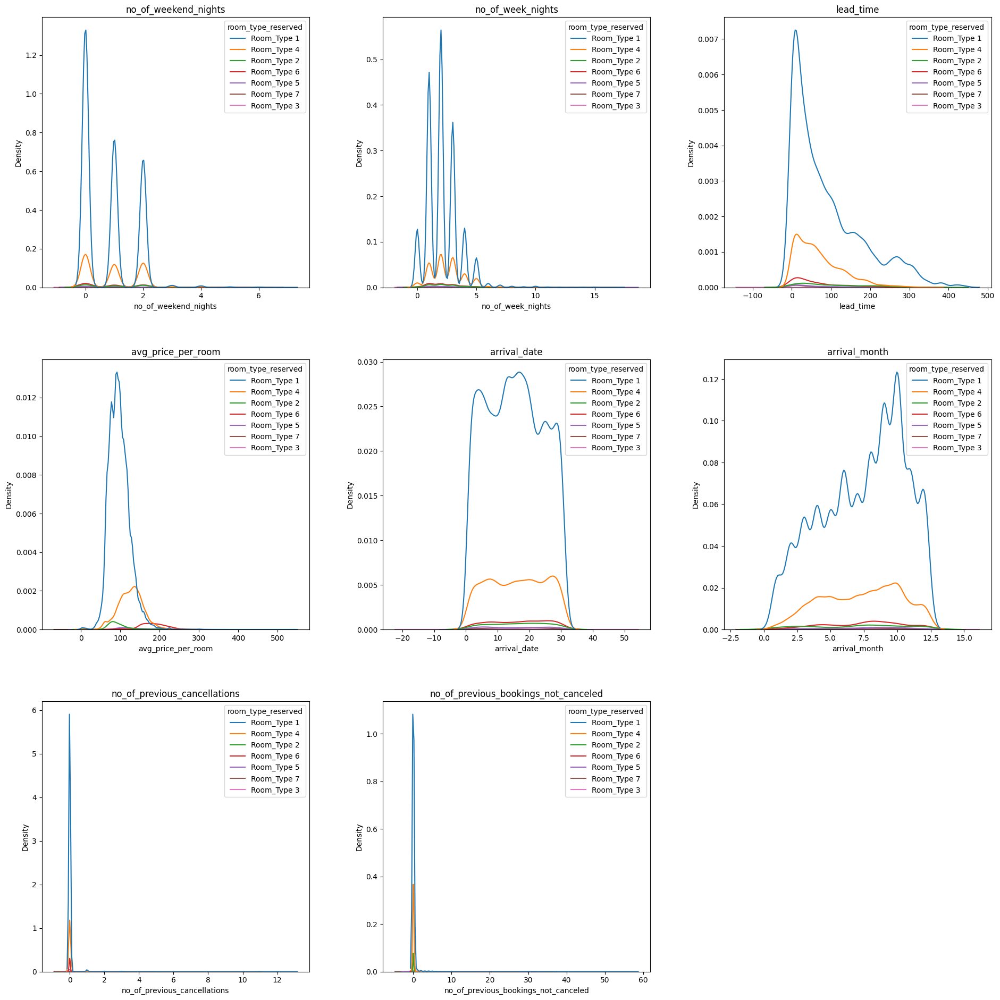

In [ ]:
plt.figure(figsize=(20,20))

for i, variable in enumerate(continuous_variables):
  plt.subplot(3, 3, i + 1)
  sns.kdeplot(data = dataset, x = dataset[variable], hue = "room_type_reserved", fill = False, warn_singular= False)
  plt.tight_layout (pad = 5)
  plt.title(variable)

plt.show()

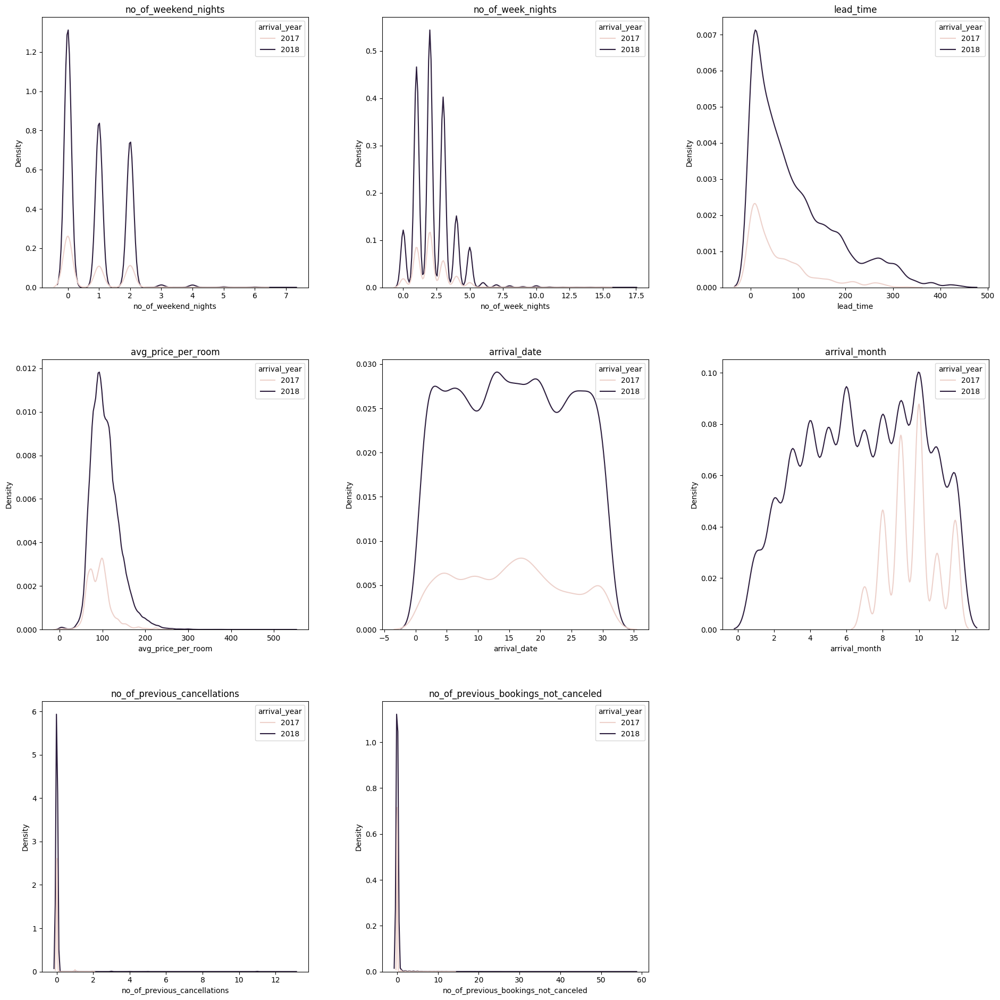

In [ ]:
plt.figure(figsize=(20,20))

for i, variable in enumerate(continuous_variables):
  plt.subplot(3, 3, i + 1)
  sns.kdeplot(data = dataset, x = dataset[variable], hue = "arrival_year", fill = False, warn_singular= False)
  plt.tight_layout (pad = 5)
  plt.title(variable)

plt.show()

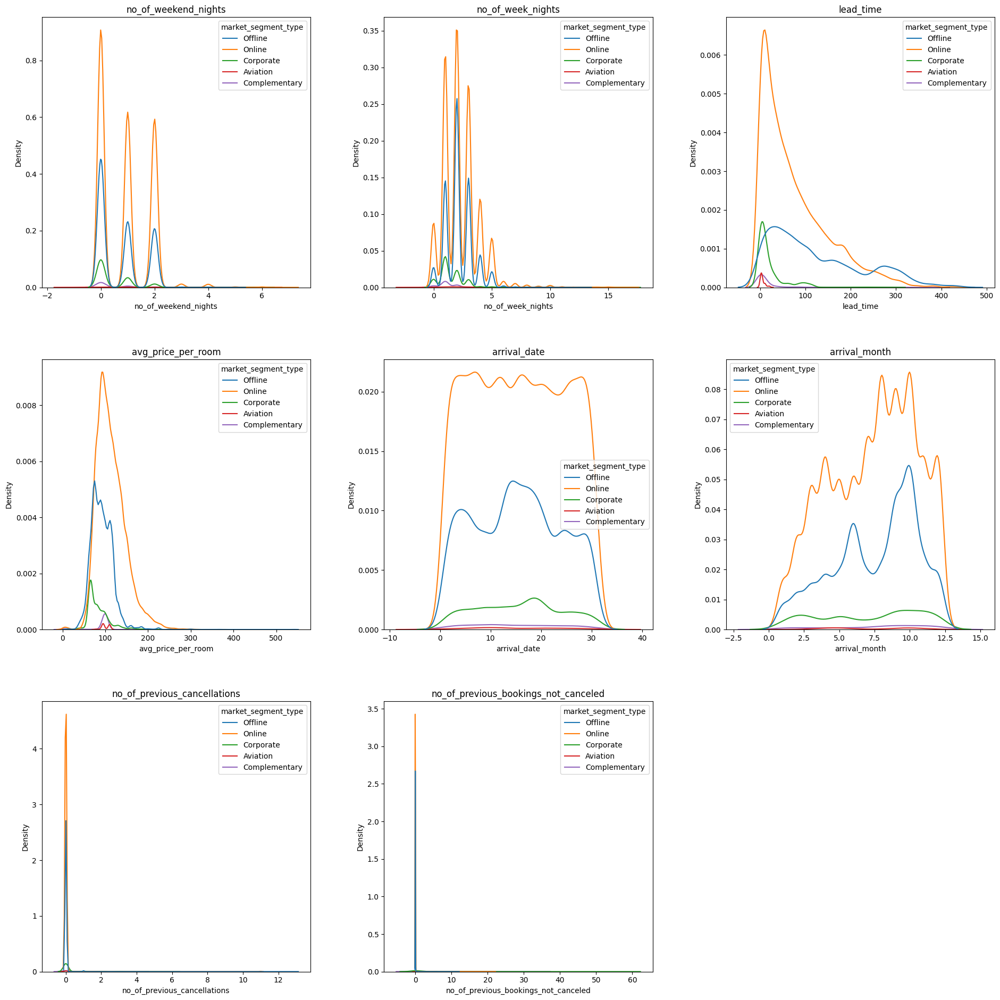

In [ ]:
plt.figure(figsize=(20,20))

for i, variable in enumerate(continuous_variables):
  plt.subplot(3, 3, i + 1)
  sns.kdeplot(data = dataset, x = dataset[variable], hue = "market_segment_type", fill = False, warn_singular= False)
  plt.tight_layout (pad = 5)
  plt.title(variable)

plt.show()

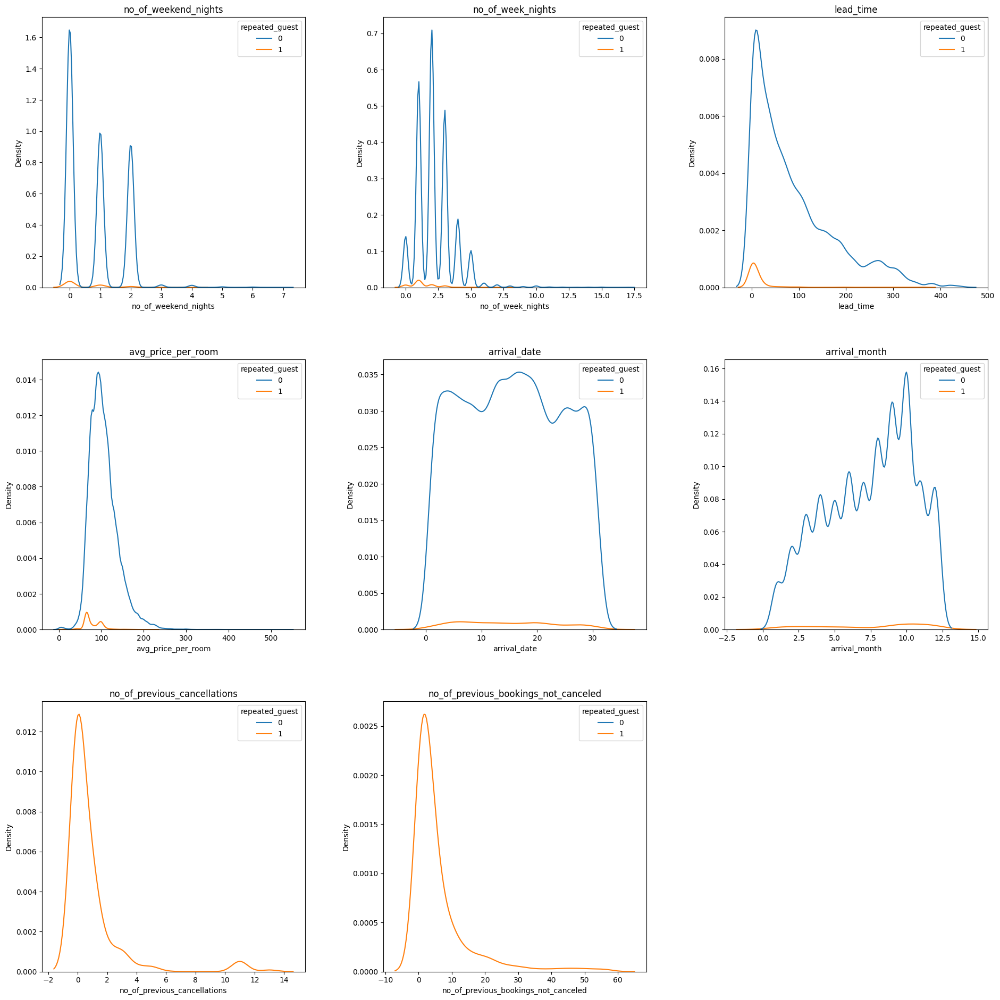

In [ ]:
plt.figure(figsize=(20,20))

for i, variable in enumerate(continuous_variables):
  plt.subplot(3, 3, i + 1)
  sns.kdeplot(data = dataset, x = dataset[variable], hue = "repeated_guest", fill = False, warn_singular= False)
  plt.tight_layout (pad = 5)
  plt.title(variable)

plt.show()

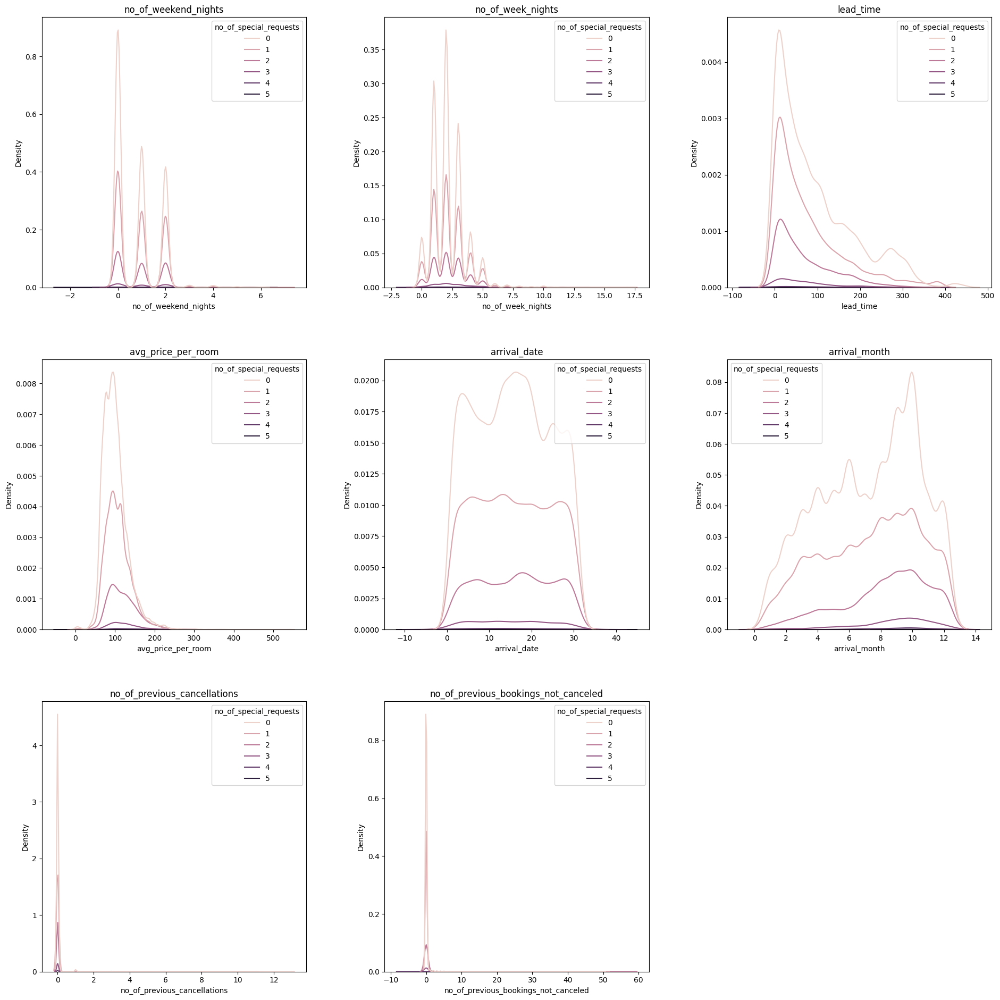

In [ ]:
plt.figure(figsize=(20,20))

for i, variable in enumerate(continuous_variables):
  plt.subplot(3, 3, i + 1)
  sns.kdeplot(data = dataset, x = dataset[variable], hue = "no_of_special_requests", fill = False, warn_singular= False)
  plt.tight_layout (pad = 5)
  plt.title(variable)

plt.show()

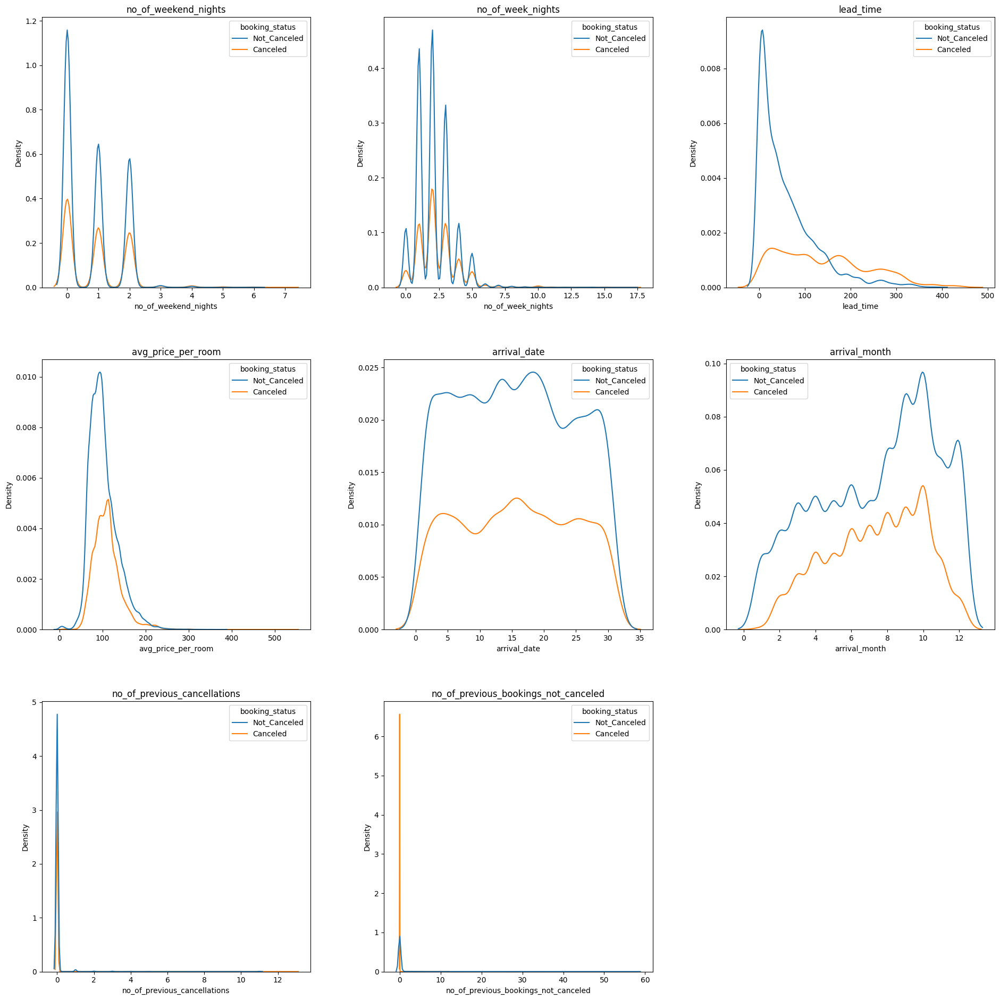

In [ ]:
plt.figure(figsize=(20,20))

for i, variable in enumerate(continuous_variables):
  plt.subplot(3, 3, i + 1)
  sns.kdeplot(data = dataset, x = dataset[variable], hue = "booking_status", fill = False, warn_singular= False)
  plt.tight_layout (pad = 5)
  plt.title(variable)

plt.show()

- Generally speaking, the higher the number of adults and/or children booked for, the higher the average price of the room tends to be, although not by much. This is understandable as more people require more space and resources.

- When we look at the number of adults booked for, we see that bookigns with 3 adults peak around the middle of the year as compared to bookings for 1 or 2 adults or bookings in general that peak around October. This might be due to scheduling preferences involving adults from more than 1 family. At the same time, we also see a dip in bookings with a single adult around the middle of the year. While not much, it seems to be a bit more than just a fluctuation, possibly again suggesting preferences.

- None of the continuous variables have a discernable pattern against the number of children booked for. The same applies to the variables of required car parking space, room type reserved, number of special requests, and booking status.

- The highest number of previous bookings not cancelled come from people who went for Meal Plan 2, despite the fact that people who chose Meal Plan 1 are far greater in general.

- When we look at arrival year, we see that in 2017 customers started making bookings only from June. This might be because the hotel could have opened its services from that time.

- We see that while following a similar trend, the market segment type of offline bookings are more evenly spread out in the lead time they take to make a booking as compared to the other types. They are less likely to make last minute bookings as compared to the other types.

- When we look at the variable of repeated guests, we see that all of the data from the variables of number of previous cancellations and number of previous bookings that weren't cancelled come exclusively from guests that have already stayed at least once. This makes sense because without being a repeated guest, there is no question of previous bookings.

### **Questions To Be Answered From EDA**

**Question 1:**

What are the busiest months in the hotel?

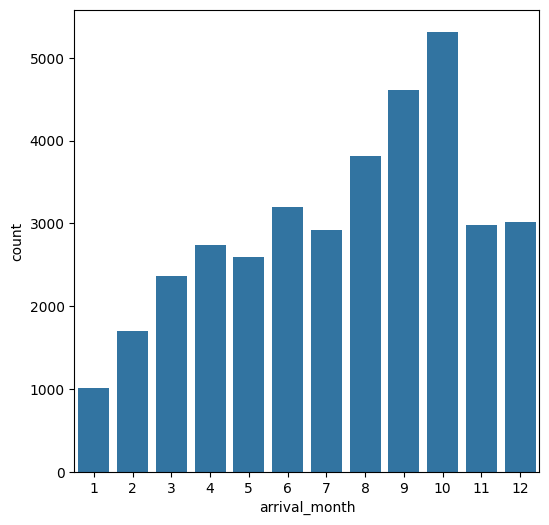

In [ ]:
# To answer this question, we can look at the distribution of the arrival_month variable:

plt.figure (figsize =(6, 6))
sns.countplot(data = dataset, x = dataset["arrival_month"])

plt.show()

- From the graph, we can see that the 10th month or October is the busiest across the entire year. We might say that August, September and October are the busiest months as a group across the year.

**Question 2:**

Which market segment do most of the guests come from?

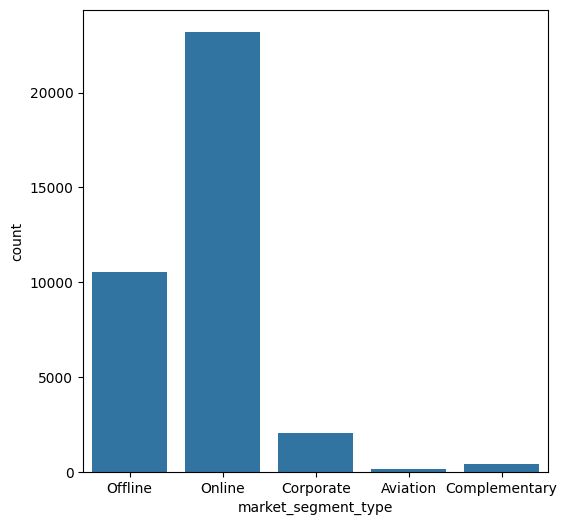

In [ ]:
# To answer this question, we can look at the distribution of the market_segment_type variable:

plt.figure (figsize =(6, 6))
sns.countplot(data = dataset, x = dataset["market_segment_type"])

plt.show()

- We can see that the vast majority of guests come from the "Online" market segment type.

**Question 3:**

Hotel rates are dynamic and change according to demand and customer demographics. What are the differences in room prices in different market segments?

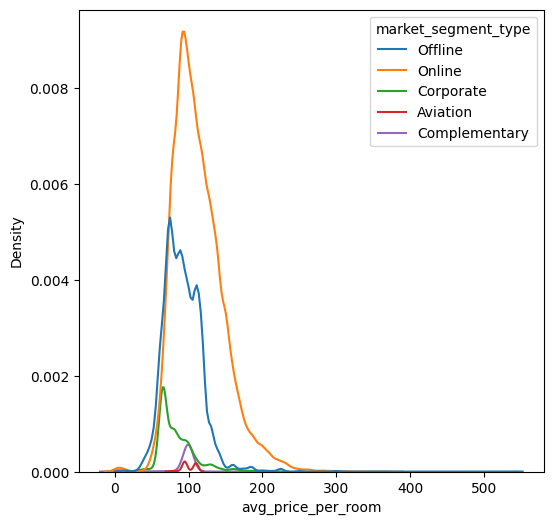

In [ ]:
# To answer this question, we can look at a breakdown of the avg_price_per_room variable by the market_segment_type variable:

plt.figure (figsize =(6, 6))
sns.kdeplot(data = dataset, x = dataset["avg_price_per_room"], hue = "market_segment_type", fill = False, warn_singular= False)

plt.show()

- The most common rates across different market segments are rather close to one another with little variation. They approximately range from about 70 Euros to about 100 Euros.

**Question 4:**

What percentage of bookings are canceled?

In [ ]:
# To answer this question, we can look at the proportion of cancellations over total bookings as a percentage:

round (((dataset ["booking_status"] == "Canceled").mean() * 100), 2)

np.float64(32.76)

- The percentage of bookings that were canceled is 32.76%

**Question 5:**

Repeating guests are the guests who stay in the hotel often and are important to brand equity. What percentage of repeating guests cancel?

In [ ]:
# To answer this question, we can again look at the proportion of cancellations over total bookings as a percentage, but this time, from within repeating guests:

subset = dataset[dataset["repeated_guest"]== 1]
round (((subset ["booking_status"] == "Canceled").mean() * 100), 2)



np.float64(1.72)

- We see that only 1.72% of repeating guests cancel, which is a good thing.

**Question 6:**

Many guests have special requirements when booking a hotel room. Do these requirements affect booking cancellation?

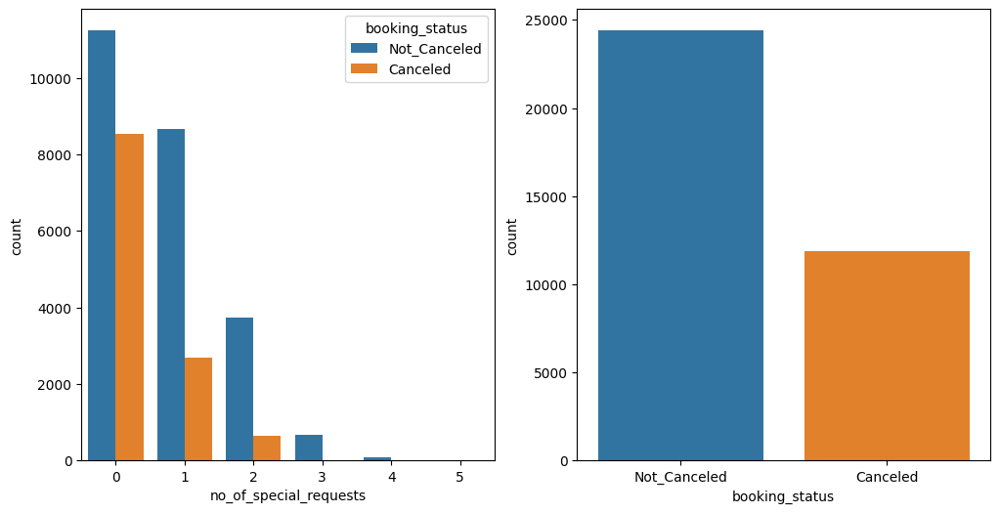

In [ ]:
# To answer this question, we can look at a breakdown of no_of_special_requests by booking_status alongside the distribution of booking_status itself to compare:

plt.figure (figsize =(12, 6))

plt.subplot(1,2,1)
sns.countplot(data = dataset, x = "no_of_special_requests", hue = "booking_status")

plt.subplot(1,2,2)
sns.countplot(data = dataset, x = "booking_status", hue = "booking_status")

plt.show()

- We see that the proportion between canceled bookings and non-canceled bookings is roughly the same across every entry for number of special requests. This means that the number of special requests does not have any significant impact on booking cancelation.

- If anything, we might say proportion of cancelations are highest with 0 special requests and keep dropping with an increasing number of special requests, suggesting that people might be less likely to cancel the more invested they are.

## **Model Building**

### **Logistic Regression Model**

In [ ]:
# Let's build our logistic regression model, fit the model onto the training dataset, then look at its summary:

modelbld = sm.Logit (y_train, x_train.astype(float))
modelfit = modelbld.fit()

print (modelfit.summary())

         Current function value: 0.426637
         Iterations: 35
                           Logit Regression Results                           
Dep. Variable:         booking_status   No. Observations:                25392
Model:                          Logit   Df Residuals:                    25364
Method:                           MLE   Df Model:                           27
Date:                Sun, 22 Mar 2026   Pseudo R-squ.:                  0.3268
Time:                        06:17:43   Log-Likelihood:                -10833.
converged:                      False   LL-Null:                       -16091.
Covariance Type:            nonrobust   LLR p-value:                     0.000
                                           coef    std err          z      P>|z|      [0.025      0.975]
--------------------------------------------------------------------------------------------------------
const                                 -990.4521    120.645     -8.210      0.000   -1226.912

/usr/local/lib/python3.12/dist-packages/statsmodels/base/model.py:607: ConvergenceWarning: Maximum Likelihood optimization failed to converge. Check mle_retvals
  warnings.warn("Maximum Likelihood optimization failed to "


In [ ]:
# Let's predict the dependant variable (booking_status) by setting a default threshold of 50%:

pred_train = modelfit.predict(x_train) > 0.5
pred_train = np.round (pred_train)

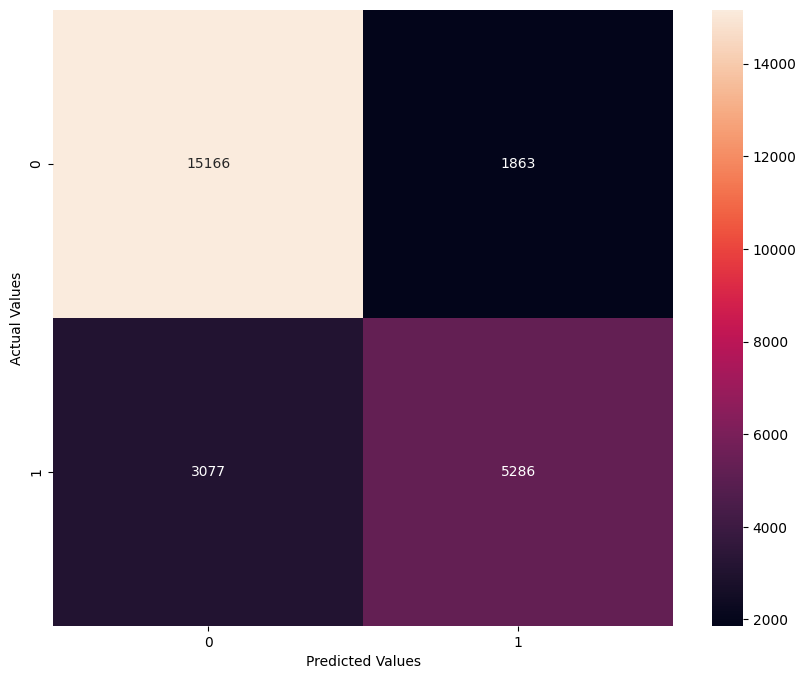

In [ ]:
# Now let's make a confusion matrix of the predicted values and actual values:

c_matrix = confusion_matrix(y_train, pred_train)
plt.figure(figsize=(10, 8))
sns.heatmap(c_matrix, annot=True, fmt="d")
plt.xlabel("Predicted Values")
plt.ylabel("Actual Values")

plt.show()

In [ ]:
# Now, let's look at the accuracy score of the model:

round (accuracy_score(y_train, pred_train), 2)

0.81

- The accuracy score of 81% is rather good, suggesting the model is performing rather satisfactorily on the training dataset.

- However, we will need to check for multicolinearity and remove statistically irrelevant variables, which we will do next.

### **Decision Tree Model**

In [ ]:
# Let's build our decision tree model, then fit the model onto the training dataset:

modelbld_dt = DecisionTreeClassifier (criterion = "gini", random_state = 1)
modelbld_dt.fit(x_train_dt, y_train_dt)

DecisionTreeClassifier(random_state=1)

In [ ]:
# Now let's look at the Accuracy and Sensitivity (or Recall) of our decision tree:

print ("Accuracy of Decision Tree on training dataset: ", round (modelbld_dt.score(x_train_dt, y_train_dt), 2))
print ("Accuracy of Decision Tree on testing dataset: ", round (modelbld_dt.score(x_test_dt, y_test_dt), 2))

print ("\n")

pred_train_dt = modelbld_dt.predict(x_train_dt)
pred_test_dt = modelbld_dt.predict(x_test_dt)

print ("Sensitivity of Decision Tree on training dataset: ", round (recall_score(y_train_dt, pred_train_dt), 2))
print ("Sensitivity of Decision Tree on testing dataset: ", round (recall_score(y_test_dt, pred_test_dt), 2))

Accuracy of Decision Tree on training dataset:  0.99
Accuracy of Decision Tree on testing dataset:  0.87


Sensitivity of Decision Tree on training dataset:  0.99
Sensitivity of Decision Tree on testing dataset:  0.81


- We see that the difference in Accuracy and Sensitivity scores between training and testing datasets is rather significant. This is expected given that the tree is not pruned and therefore performs really well on the training dataset but doesnt do well on the testing dataset.

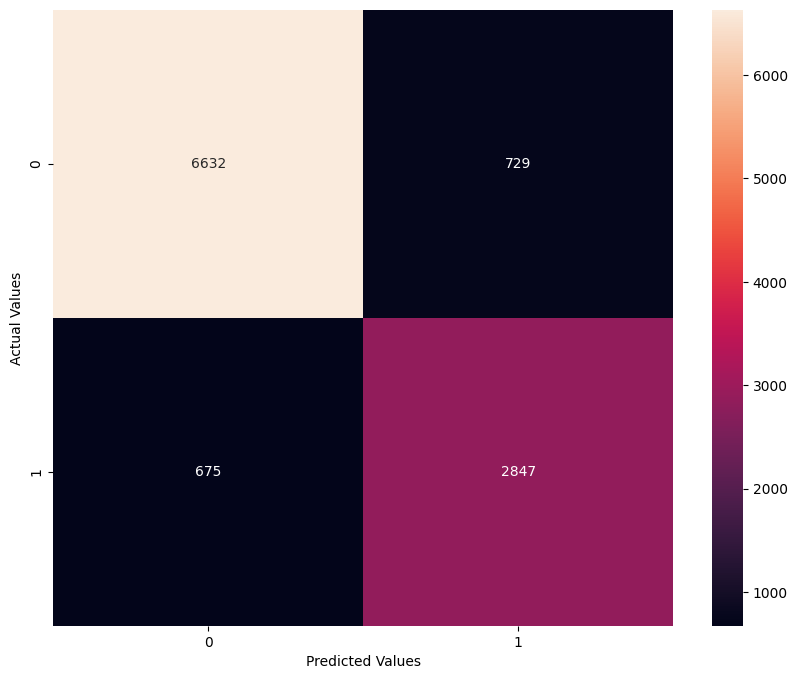

In [ ]:
# Let's quickly look at the confusion matrix of our unpruned tree on the test dataset:

c_matrix = confusion_matrix(y_test_dt, pred_test_dt)
plt.figure(figsize=(10, 8))
sns.heatmap(c_matrix, annot=True, fmt="d")
plt.xlabel("Predicted Values")
plt.ylabel("Actual Values")

plt.show()

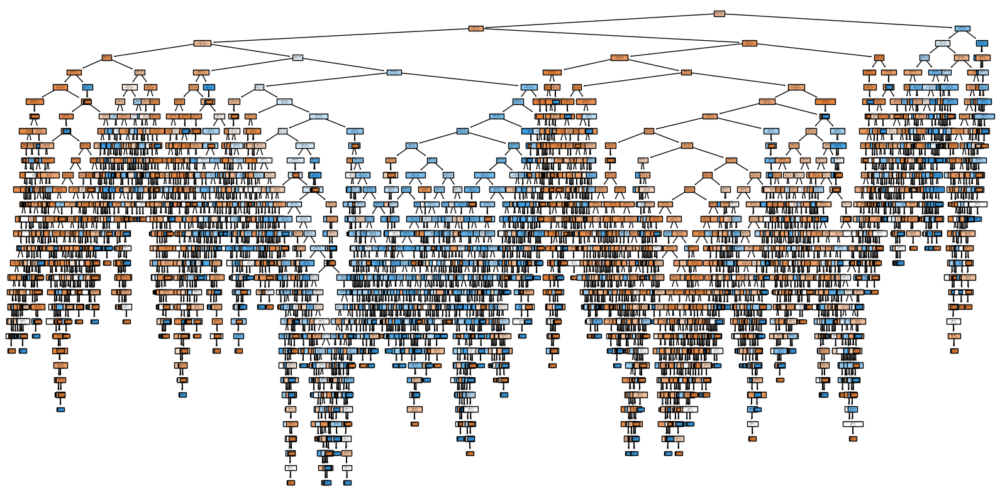

In [ ]:
# Let's also make a visualisation of our tree to see how complex it is:

plt.figure(figsize=(20,10))
plot_tree(modelbld_dt, feature_names=x_train_dt.columns, class_names=True, filled=True)
plt.show()

- As we can see, that is incredibly complex and needs to be pruned.

In [ ]:
# Let's get the importance of each variable:

importances = modelbld_dt.feature_importances_

importances_dataset = pd.DataFrame([importances], index=["importances"], columns=x_train_dt.columns).T
importances_dataset

,importances
no_of_adults,0.034219
no_of_children,0.003239
no_of_weekend_nights,0.039870
no_of_week_nights,0.045116
required_car_parking_space,0.006804
lead_time,0.349630
arrival_year,0.013834
arrival_month,0.061648
arrival_date,0.085561
repeated_guest,0.000416


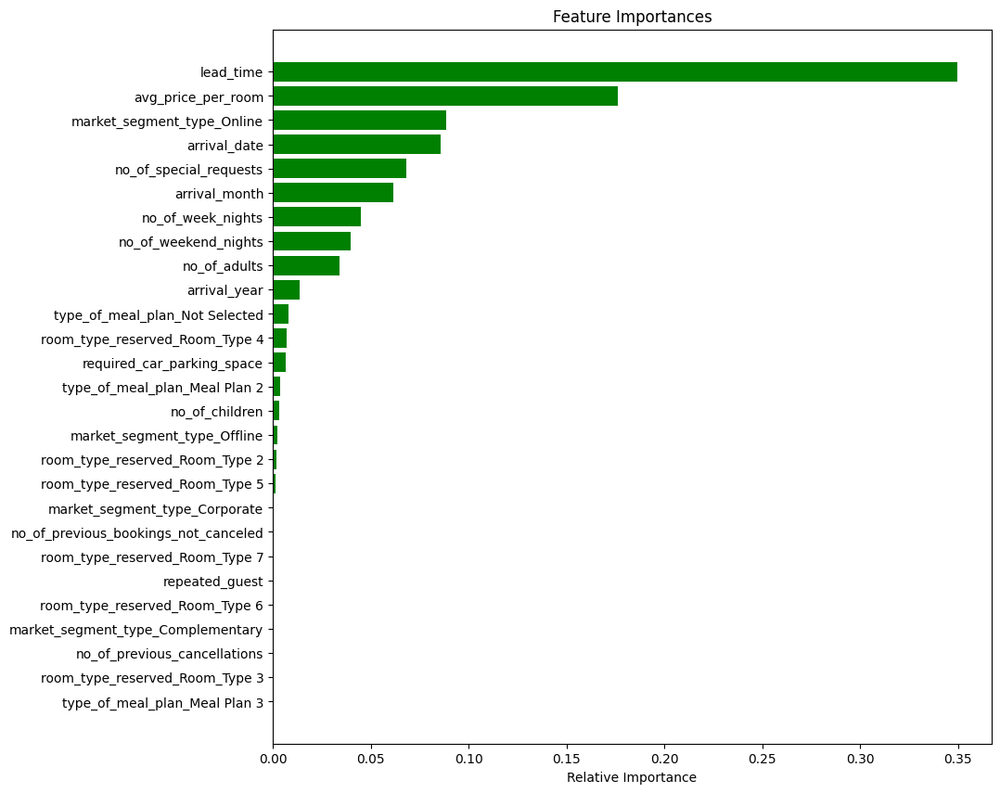

In [ ]:
# Now, let's also visualise them:

indices = np.argsort (importances)

plt.figure (figsize=(10,10))
plt.barh (range(len(indices)), importances[indices], color= "green", align= "center")
plt.yticks (range(len(indices)), [x_train_dt.columns[i] for i in indices])
plt.title ("Feature Importances")
plt.xlabel ("Relative Importance")

plt.show()

- The visualisation makes it easy for us to understand relative importances. It suggests that lead_time is the variable that has played the most important role of all in the decision tree.

## **Model Performance Improvement**

### **Logistic Regression Model**

In [ ]:
# Let's start by checking for multicolinearity between our independant variables.

# We will do this by getting a list of the Variance Inflation Factors for every independent variable:

VIF_list = pd.Series ([variance_inflation_factor (x_train, i) for i in range (x_train.shape[1])], index = x_train.columns)

VIF_list.round(2)

,0
const,39322032.50
no_of_adults,1.33
no_of_children,1.95
no_of_weekend_nights,1.07
no_of_week_nights,1.10
required_car_parking_space,1.04
lead_time,1.40
arrival_year,1.43
arrival_month,1.28
arrival_date,1.01


- We see that all variables have VIFs close to 1 which is great. However, there are 3-4 variables with high VIFs which we will need to address.

- We will remove these variables one by one to see how the VIFs change.

In [ ]:
# Let's start by dropping the "market_segment_type_Online" variable, then redoing our regression to see how the accuracy metric has changed:

x_train_2 = x_train.drop ("market_segment_type_Online", axis = 1)

modelbld_2 = sm.Logit (y_train, x_train_2.astype(float))
modelfit_2 = modelbld_2.fit()

pred_train_2 = modelfit_2.predict(x_train_2) > 0.5
pred_train_2 = np.round (pred_train_2)

print ("Initial Accuracy: ", round (accuracy_score(y_train, pred_train), 2), "\n", "Current Accuracy: ", round (accuracy_score(y_train, pred_train_2), 2))

# We can see that the accuracy score has not changed. We will therefore confirm the drop of the "market_segment_type_Online" variable.

         Current function value: 0.426690
         Iterations: 35
Initial Accuracy:  0.81 
 Current Accuracy:  0.81


/usr/local/lib/python3.12/dist-packages/statsmodels/base/model.py:607: ConvergenceWarning: Maximum Likelihood optimization failed to converge. Check mle_retvals
  warnings.warn("Maximum Likelihood optimization failed to "


In [ ]:
# Now let's check again for the Variance Inflation Factors:

VIF_list = pd.Series ([variance_inflation_factor (x_train_2, i) for i in range (x_train_2.shape[1])], index = x_train_2.columns)

VIF_list.round(2)

,0
const,39237707.43
no_of_adults,1.32
no_of_children,1.95
no_of_weekend_nights,1.07
no_of_week_nights,1.10
required_car_parking_space,1.04
lead_time,1.40
arrival_year,1.42
arrival_month,1.28
arrival_date,1.01


- Great, we can now see that there is no variable left that has a VIF outside the vicinity of 1. We therefore can confirm multicolinearity is no longer present in our dataset.

In [ ]:
# Now let's move onto removing statistically irrelevant variables one by one by looking at their p-values.

# Let's start by looking at the summary of our latest model:

print (modelfit_2.summary())

                           Logit Regression Results                           
Dep. Variable:         booking_status   No. Observations:                25392
Model:                          Logit   Df Residuals:                    25365
Method:                           MLE   Df Model:                           26
Date:                Sun, 22 Mar 2026   Pseudo R-squ.:                  0.3267
Time:                        06:17:53   Log-Likelihood:                -10835.
converged:                      False   LL-Null:                       -16091.
Covariance Type:            nonrobust   LLR p-value:                     0.000
                                           coef    std err          z      P>|z|      [0.025      0.975]
--------------------------------------------------------------------------------------------------------
const                                 -999.9336    120.475     -8.300      0.000   -1236.060    -763.807
no_of_adults                             0.1345      

- There are a few variables with very high p-values. We will start removing them one by one.

In [ ]:
# Let's start by removing the variable with the highest p-value from the dataset, which is "market_segment_type_Complementary":

x_train_3 = x_train_2.drop ("market_segment_type_Complementary", axis = 1)

modelbld_3 = sm.Logit (y_train, x_train_3.astype(float))
modelfit_3 = modelbld_3.fit()

pred_train_3 = modelfit_3.predict(x_train_3) > 0.5
pred_train_3 = np.round (pred_train_3)

print ("Initial Accuracy: ", round (accuracy_score(y_train, pred_train_2), 2), "\n", "Current Accuracy: ", round (accuracy_score(y_train, pred_train_3), 2))

# We can see that the accuracy score has dropped by 0.01. This is negligible and we will therefore confirm the drop of the "market_segment_type_Complementary" variable.

Optimization terminated successfully.
         Current function value: 0.428056
         Iterations 13
Initial Accuracy:  0.81 
 Current Accuracy:  0.8


In [ ]:
# Let's look at the summary of our latest model:

print (modelfit_3.summary())

                           Logit Regression Results                           
Dep. Variable:         booking_status   No. Observations:                25392
Model:                          Logit   Df Residuals:                    25366
Method:                           MLE   Df Model:                           25
Date:                Sun, 22 Mar 2026   Pseudo R-squ.:                  0.3245
Time:                        06:17:54   Log-Likelihood:                -10869.
converged:                       True   LL-Null:                       -16091.
Covariance Type:            nonrobust   LLR p-value:                     0.000
                                           coef    std err          z      P>|z|      [0.025      0.975]
--------------------------------------------------------------------------------------------------------
const                                -1011.1523    119.992     -8.427      0.000   -1246.332    -775.973
no_of_adults                             0.1454      

In [ ]:
# Let's remove the variable with the highest p-value from this dataset, which is "arrival_date":

x_train_4 = x_train_3.drop ("arrival_date", axis = 1)

modelbld_4 = sm.Logit (y_train, x_train_4.astype(float))
modelfit_4 = modelbld_4.fit()

pred_train_4 = modelfit_4.predict(x_train_4) > 0.5
pred_train_4 = np.round (pred_train_4)

print ("Initial Accuracy: ", round (accuracy_score(y_train, pred_train_2), 2), "\n", "Current Accuracy: ", round (accuracy_score(y_train, pred_train_4), 2))

# We can see that the accuracy score has not changed. We will therefore confirm the drop of the "arrival_date" variable.

Optimization terminated successfully.
         Current function value: 0.428057
         Iterations 13
Initial Accuracy:  0.81 
 Current Accuracy:  0.8


In [ ]:
# Let's look at the summary of our latest model:

print (modelfit_4.summary())

                           Logit Regression Results                           
Dep. Variable:         booking_status   No. Observations:                25392
Model:                          Logit   Df Residuals:                    25367
Method:                           MLE   Df Model:                           24
Date:                Sun, 22 Mar 2026   Pseudo R-squ.:                  0.3245
Time:                        06:17:54   Log-Likelihood:                -10869.
converged:                       True   LL-Null:                       -16091.
Covariance Type:            nonrobust   LLR p-value:                     0.000
                                           coef    std err          z      P>|z|      [0.025      0.975]
--------------------------------------------------------------------------------------------------------
const                                -1011.1299    119.996     -8.426      0.000   -1246.317    -775.943
no_of_adults                             0.1457      

In [ ]:
# Let's remove the variable with the highest p-value from this dataset, which is "room_type_reserved_Room_Type 3":

x_train_5 = x_train_4.drop ("room_type_reserved_Room_Type 3", axis = 1)

modelbld_5 = sm.Logit (y_train, x_train_5.astype(float))
modelfit_5 = modelbld_5.fit()

pred_train_5 = modelfit_5.predict(x_train_5) > 0.5
pred_train_5 = np.round (pred_train_5)

print ("Initial Accuracy: ", round (accuracy_score(y_train, pred_train_2), 2), "\n", "Current Accuracy: ", round (accuracy_score(y_train, pred_train_5), 2))

# We can see that the accuracy score has not changed. We will therefore confirm the drop of the "room_type_reserved_Room_Type 3" variable.

Optimization terminated successfully.
         Current function value: 0.428060
         Iterations 13
Initial Accuracy:  0.81 
 Current Accuracy:  0.8


In [ ]:
# Let's look at the summary of our latest model:

print (modelfit_5.summary())

                           Logit Regression Results                           
Dep. Variable:         booking_status   No. Observations:                25392
Model:                          Logit   Df Residuals:                    25368
Method:                           MLE   Df Model:                           23
Date:                Sun, 22 Mar 2026   Pseudo R-squ.:                  0.3245
Time:                        06:17:54   Log-Likelihood:                -10869.
converged:                       True   LL-Null:                       -16091.
Covariance Type:            nonrobust   LLR p-value:                     0.000
                                           coef    std err          z      P>|z|      [0.025      0.975]
--------------------------------------------------------------------------------------------------------
const                                -1011.4154    119.991     -8.429      0.000   -1246.594    -776.237
no_of_adults                             0.1457      

In [ ]:
# Let's remove the variable with the highest p-value from this dataset, which is "type_of_meal_plan_Meal Plan 3":

x_train_6 = x_train_5.drop ("type_of_meal_plan_Meal Plan 3", axis = 1)

modelbld_6 = sm.Logit (y_train, x_train_6.astype(float))
modelfit_6 = modelbld_6.fit()

pred_train_6 = modelfit_6.predict(x_train_6) > 0.5
pred_train_6 = np.round (pred_train_6)

print ("Initial Accuracy: ", round (accuracy_score(y_train, pred_train_2), 2), "\n", "Current Accuracy: ", round (accuracy_score(y_train, pred_train_6), 2))

# We can see that the accuracy score has not changed. We will therefore confirm the drop of the "type_of_meal_plan_Meal Plan 3" variable.

Optimization terminated successfully.
         Current function value: 0.428073
         Iterations 13
Initial Accuracy:  0.81 
 Current Accuracy:  0.8


In [ ]:
# Let's look at the summary of our latest model:

print (modelfit_6.summary())

                           Logit Regression Results                           
Dep. Variable:         booking_status   No. Observations:                25392
Model:                          Logit   Df Residuals:                    25369
Method:                           MLE   Df Model:                           22
Date:                Sun, 22 Mar 2026   Pseudo R-squ.:                  0.3245
Time:                        06:17:55   Log-Likelihood:                -10870.
converged:                       True   LL-Null:                       -16091.
Covariance Type:            nonrobust   LLR p-value:                     0.000
                                           coef    std err          z      P>|z|      [0.025      0.975]
--------------------------------------------------------------------------------------------------------
const                                -1009.9215    119.975     -8.418      0.000   -1245.069    -774.774
no_of_adults                             0.1457      

In [ ]:
# Let's remove the variable with the highest p-value from this dataset, which is "no_of_previous_bookings_not_canceled":

x_train_7 = x_train_6.drop ("no_of_previous_bookings_not_canceled", axis = 1)

modelbld_7 = sm.Logit (y_train, x_train_7.astype(float))
modelfit_7 = modelbld_7.fit()

pred_train_7 = modelfit_7.predict(x_train_7) > 0.5
pred_train_7 = np.round (pred_train_7)

print ("Initial Accuracy: ", round (accuracy_score(y_train, pred_train_2), 2), "\n", "Current Accuracy: ", round (accuracy_score(y_train, pred_train_7), 2))

# We can see that the accuracy score has not changed. We will therefore confirm the drop of the "no_of_previous_bookings_not_canceled" variable.

Optimization terminated successfully.
         Current function value: 0.428129
         Iterations 11
Initial Accuracy:  0.81 
 Current Accuracy:  0.8


In [ ]:
# Let's look at the summary of our latest model:

print (modelfit_7.summary())

                           Logit Regression Results                           
Dep. Variable:         booking_status   No. Observations:                25392
Model:                          Logit   Df Residuals:                    25370
Method:                           MLE   Df Model:                           21
Date:                Sun, 22 Mar 2026   Pseudo R-squ.:                  0.3244
Time:                        06:17:55   Log-Likelihood:                -10871.
converged:                       True   LL-Null:                       -16091.
Covariance Type:            nonrobust   LLR p-value:                     0.000
                                     coef    std err          z      P>|z|      [0.025      0.975]
--------------------------------------------------------------------------------------------------
const                          -1008.5333    119.988     -8.405      0.000   -1243.706    -773.360
no_of_adults                       0.1457      0.038      3.833      0.

- Great, there is no variable left for which the p-value is greater than 0.05. This means we have removed all statistically irrelevant variables from our dataset too.

In [ ]:
# Now, we will move to interpreting the coefficients. For that, we need to look at the logistic model with respect to the odds ratio.

# We know log of odds ratio is linear. Therefore, odds ratio itself is e to the power of the linear equation:

odds = np.exp (modelfit_7.params)
percentage_change_odds = (odds - 1) * 100

odds_dataset = pd.DataFrame([odds, percentage_change_odds], index=["odds", "percentage_change_odds"], columns=x_train_7.columns).T
odds_dataset

,odds,percentage_change_odds
const,0.000000,-100.000000
no_of_adults,1.156795,15.679537
no_of_children,1.164048,16.404772
no_of_weekend_nights,1.119619,11.961941
no_of_week_nights,1.045991,4.599119
required_car_parking_space,0.207140,-79.285976
lead_time,1.015789,1.578901
arrival_year,1.645973,64.597290
arrival_month,0.958934,-4.106568
repeated_guest,0.058729,-94.127138


- Great, now we can interpret the coefficients of the variables.

- We will look at the percentage_change_odds column. For every unit change in the corresponding variable the odds of cancellation will go up or go down (depending on whether entry is positive or negetive) by a percentage of the number mentioned in the percentage_change_odds column.

- In this light, we see the highest positive influence on the cancelation odds is from variables such as arrival_year, type_of_meal_plan_Not Selected, no_of_previous_cancellations. In other words, for every unit increase in these variables while all else are constant, the cancelation odds also go up by the specified percentage.

- The highest negetive influence on the cancelation odds comes from variables such as repeated_guest, market_segment_type_Offline, and no_of_special_requests. In other words, for every unit increase in these variables while all else are constant, the cancelation odds go down by the specified percentage.

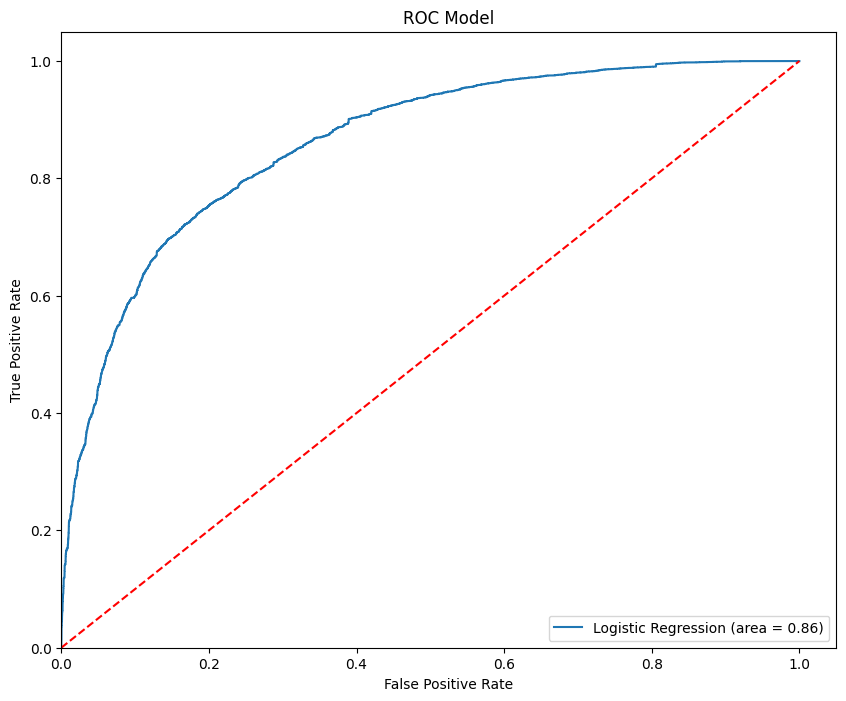

In [ ]:
# We will now move onto constructing an ROC curve for our model, and picking the threshold for our final model that corresponds to the best balance between True Positive Rate and False Positive Rate:

roc_model = roc_auc_score (y_train, modelfit_7.predict(x_train_7))
fpr, tpr, thresholds = roc_curve (y_train, modelfit_7.predict(x_train_7))

plt.figure (figsize=(10,8))
plt.plot (fpr, tpr, label = "Logistic Regression (area = %0.2f)" % roc_model)
plt.plot ([0,1], [0,1], "r--")
plt.xlim (0,1.05)
plt.ylim (0, 1.05)
plt.xlabel("False Positive Rate")
plt.ylabel ("True Positive Rate")
plt.legend (loc="lower right")
plt.title ("ROC Model")

plt.show()

- We see that the area under the curve for our model is 0.86, which is rather good. It means our model is doing a good job predicting the probabilities of outcomes.

In [ ]:
# Let's now look at the threshold that corresponds to the best balance between True Positive Rate and False Positive Rate (this would be the elbow of the ROC curve):

# We essentially want to maximise TPR-FPR, and find the threshold that corresponds to that.

J = tpr - fpr
optimal_point_on_curve = np.argmax(J)

optimal_threshold = thresholds[optimal_point_on_curve]
print (round ((optimal_threshold), 2))

0.36


- The optimal threshold is 0.36 or at 36%.

- Since we're trying to predict when someone might cancel, false negetives are more expensive than false positives. In other words, thinking someone might not cancel while they end up cancelling is more expensive than thinking they might cancel while they end up going through with the booking.

- Hence, it might make more sense to go with a threshold that is lower than the optimal one. However, we will keep the optimal threshold for our final model to keep it objective.

In [ ]:
# Let's now define our final prediction models on the training dataset:

pred_train_final = modelfit_7.predict(x_train_7) > 0.36
pred_train_final = np.round (pred_train_final)

# Let's drop variables on our x_test dataset corresponding to ones we dropped on our x_train dataset, then define our prediction models on the testing dataset:

x_test = x_test.drop (["arrival_date", "no_of_previous_bookings_not_canceled", "type_of_meal_plan_Meal Plan 3", "room_type_reserved_Room_Type 3", "market_segment_type_Complementary", "market_segment_type_Online"], axis=1)

pred_test_final = modelfit_7.predict(x_test) > 0.36
pred_test_final = np.round (pred_test_final)

# Now, let's get accuracy scores for our final model on the training and testing datasets to compare:

print ("Accuracy Score on training dataset: ", round (accuracy_score (y_train, pred_train_final), 2))
print ("Accuracy Score on testing dataset: ", round (accuracy_score (y_test, pred_test_final), 2))

Accuracy Score on training dataset:  0.79
Accuracy Score on testing dataset:  0.79


- While the accuracy for our final model on the training dataset is slightly lesser than when our threshold was at 0.50, we see that our accuracy for our final model across both training and testing datasets is exactly the same. This is a very positive sign that our model is performing well.

In [ ]:
# Let's check the metrics of Accuracy, Sensitivity and Specificity across our old and new models to see how they compare:

pred_test = modelfit_7.predict(x_test) > 0.50
pred_test = np.round (pred_test)

# Confusion matrix of our old model:

tn_1, fp_1, fn_1, tp_1 = confusion_matrix(y_train, pred_train_7).ravel()
tn_2, fp_2, fn_2, tp_2 = confusion_matrix(y_test, pred_test).ravel()

# Confusion matrix of our new model:

tn_3, fp_3, fn_3, tp_3 = confusion_matrix(y_train, pred_train_final).ravel()
tn_4, fp_4, fn_4, tp_4 = confusion_matrix(y_test, pred_test_final).ravel()

In [ ]:
print ("Old Accuracy Score on training dataset: ", round (accuracy_score (y_train, pred_train_7),2))
print ("Old Accuracy Score on testing dataset: ", round (accuracy_score (y_test, pred_test), 2))

print ("Old Sensitivity on training dataset: ", round (tp_1 / (tp_1 + fn_1), 2))
print ("Old Sensitivity on testing dataset: ", round (tp_2 / (tp_2 + fn_2),2))

print ("Old Specificity on training dataset: ", round (tn_1 / (tn_1 + fp_1), 2))
print ("Old Specificity on testing dataset: ", round (tn_2 / (tn_2 + fp_2), 2))

print ("\n")

print ("New Accuracy Score on training dataset: ", round (accuracy_score (y_train, pred_train_final),2))
print ("New Accuracy Score on testing dataset: ", round (accuracy_score (y_test, pred_test_final), 2))

print ("New Sensitivity on training dataset: ", round (tp_3 / (tp_3 + fn_3), 2))
print ("New Sensitivity on testing dataset: ", round (tp_4 / (tp_4 + fn_4), 2))

print ("New Specificity on training dataset: ", round (tn_3 / (tn_3 + fp_3), 2))
print ("New Specificity on testing dataset: ", round (tn_4 / (tn_4 + fp_4), 2))


Old Accuracy Score on training dataset:  0.8
Old Accuracy Score on testing dataset:  0.8
Old Sensitivity on training dataset:  0.63
Old Sensitivity on testing dataset:  0.62
Old Specificity on training dataset:  0.89
Old Specificity on testing dataset:  0.89


New Accuracy Score on training dataset:  0.79
New Accuracy Score on testing dataset:  0.79
New Sensitivity on training dataset:  0.74
New Sensitivity on testing dataset:  0.75
New Specificity on training dataset:  0.81
New Specificity on testing dataset:  0.82


- As we can see, for a really small dip in Accuracy (0.01), our Sensitivity has shot up by a lot in our new model (by about 0.11), which enables us to conclude that the final model is better.

### **Pre-Pruned Decision Tree Model**

In [ ]:
# Let's run a grid search using cross validation for hyperparameter tuning so that our tree is pre-pruned using the best set of hyperparameters:

estimator = DecisionTreeClassifier (random_state = 1)

hyperparameters = {"max_depth": np.arange (1,10), "min_samples_leaf": [1,2,5,7,10,15,20], "max_leaf_nodes": [1,2,5,7,10], "min_impurity_decrease": [0.001, 0.01, 0.1]}

acc_scorer = make_scorer(recall_score)

grid_srch = GridSearchCV (estimator, hyperparameters, scoring = acc_scorer, cv=5)
grid_srch = grid_srch.fit (x_train_dt, y_train_dt)

estimator = grid_srch.best_estimator_
estimator.fit(x_train_dt, y_train_dt)

/usr/local/lib/python3.12/dist-packages/sklearn/model_selection/_validation.py:528: FitFailedWarning: 
945 fits failed out of a total of 4725.
The score on these train-test partitions for these parameters will be set to nan.
If these failures are not expected, you can try to debug them by setting error_score='raise'.

Below are more details about the failures:
--------------------------------------------------------------------------------
945 fits failed with the following error:
Traceback (most recent call last):
  File "/usr/local/lib/python3.12/dist-packages/sklearn/model_selection/_validation.py", line 866, in _fit_and_score
    estimator.fit(X_train, y_train, **fit_params)
  File "/usr/local/lib/python3.12/dist-packages/sklearn/base.py", line 1382, in wrapper
    estimator._validate_params()
  File "/usr/local/lib/python3.12/dist-packages/sklearn/base.py", line 436, in _validate_params
    validate_parameter_constraints(
  File "/usr/local/lib/python3.12/dist-packages/sklearn/uti

DecisionTreeClassifier(max_depth=np.int64(3), max_leaf_nodes=5,
                       min_impurity_decrease=0.001, random_state=1)

- We see that this decision tree has a maximum depth of 3, maximum number of leaves of 5 and a minimum impurity decrease of 0.001.

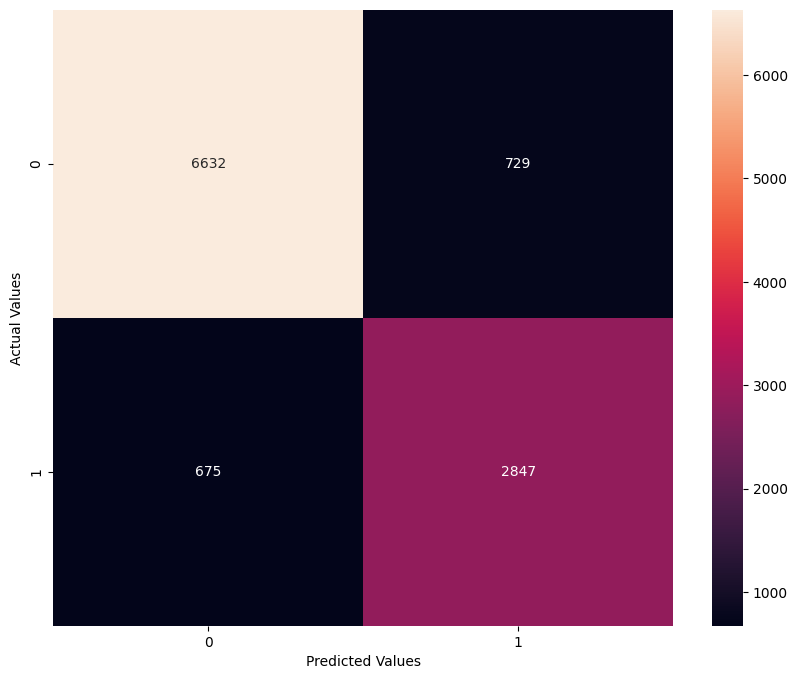

In [ ]:
# Let's look at the confusion matrix of our pruned tree on the test dataset:

pred_train_dt_prepruned = estimator.predict(x_train_dt)
pred_test_dt_prepruned = estimator.predict(x_test_dt)

c_matrix_prepruned = confusion_matrix(y_test_dt, pred_test_dt_prepruned)
plt.figure(figsize=(10, 8))
sns.heatmap(c_matrix, annot=True, fmt="d")
plt.xlabel("Predicted Values")
plt.ylabel("Actual Values")

plt.show()

In [ ]:
# Now let's see the Accuracy and Sensitivity (Recall) scores of our pruned tree against the previous unpruned tree:

print ("Unpruned Tree: \n")

print ("Accuracy of Decision Tree on training dataset: ", round (modelbld_dt.score(x_train_dt, y_train_dt), 2))
print ("Accuracy of Decision Tree on testing dataset: ", round (modelbld_dt.score(x_test_dt, y_test_dt), 2))

print ("\n")

print ("Sensitivity of Decision Tree on training dataset: ", round (recall_score(y_train_dt, pred_train_dt), 2))
print ("Sensitivity of Decision Tree on testing dataset: ", round (recall_score(y_test_dt, pred_test_dt), 2))

print ("\n\n")
print ("Prepruned Tree: \n")

print ("Accuracy of Decision Tree on training dataset: ", round (estimator.score(x_train_dt, y_train_dt), 2))
print ("Accuracy of Decision Tree on testing dataset: ", round (estimator.score(x_test_dt, y_test_dt), 2))

print ("\n")

print ("Sensitivity of Decision Tree on training dataset: ", round (recall_score(y_train_dt, pred_train_dt_prepruned), 2))
print ("Sensitivity of Decision Tree on testing dataset: ", round (recall_score(y_test_dt, pred_test_dt_prepruned), 2))

Unpruned Tree: 

Accuracy of Decision Tree on training dataset:  0.99
Accuracy of Decision Tree on testing dataset:  0.87


Sensitivity of Decision Tree on training dataset:  0.99
Sensitivity of Decision Tree on testing dataset:  0.81



Prepruned Tree: 

Accuracy of Decision Tree on training dataset:  0.77
Accuracy of Decision Tree on testing dataset:  0.77


Sensitivity of Decision Tree on training dataset:  0.76
Sensitivity of Decision Tree on testing dataset:  0.77


- We see that while both Accuracy and Sensitivity have dropped on the pruned tree, the metrics are almost identical to one another on the pruned tree, meaning that its fit is appropriate (it is not overfit).

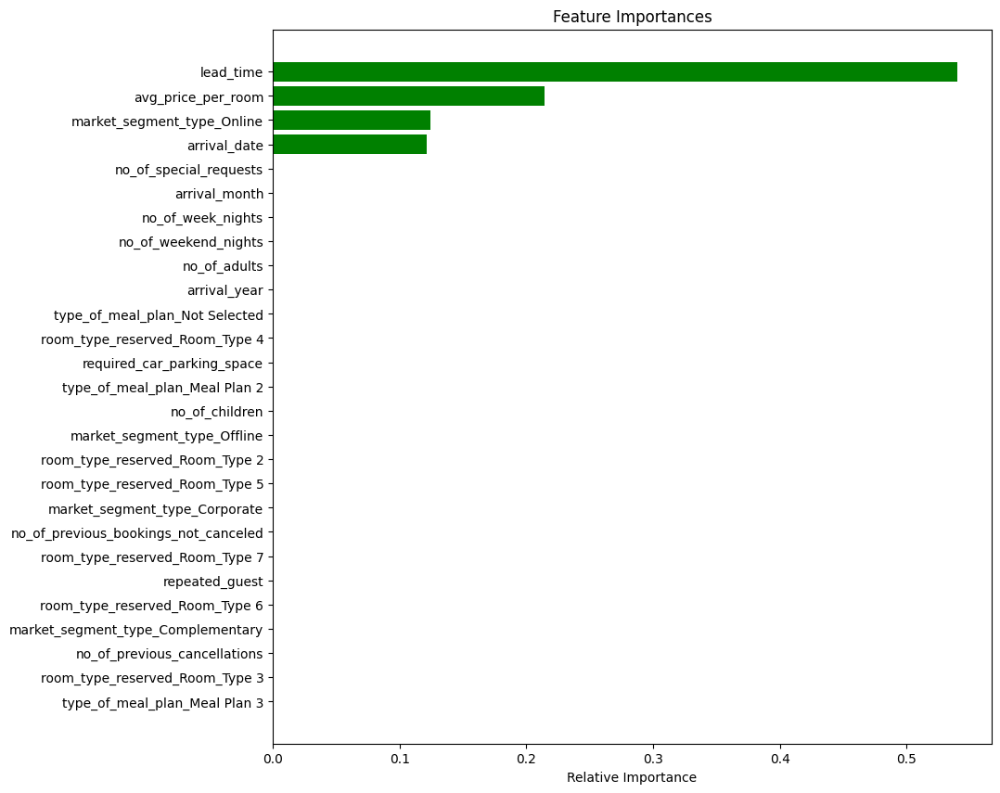

In [ ]:
# Let's quickly look at the importances of the variables:

importances_prepruned = estimator.feature_importances_

indices_prepruned = np.argsort (importances_prepruned)

plt.figure (figsize=(10,10))
plt.barh (range(len(indices)), importances_prepruned[indices_prepruned], color= "green", align= "center")
plt.yticks (range(len(indices)), [x_train_dt.columns[i] for i in indices])
plt.title ("Feature Importances")
plt.xlabel ("Relative Importance")

plt.show()

- We see that the first four most important variables have been retained with their order in the pruned tree as compared to the unpruned tree.

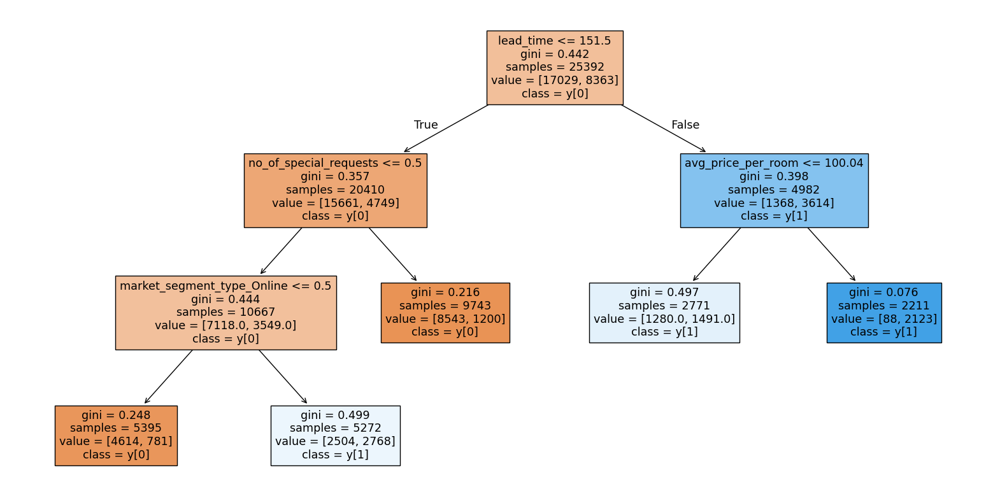

In [ ]:
# Now let's visualise the tree to see how much simpler it's gotten:

plt.figure(figsize=(20,10))
plot_tree(estimator, feature_names=x_train_dt.columns, class_names=True, filled=True)
plt.show()

- There we go, it's much simpler, and more effective.

### **Post-Pruned Decision Tree Model or Cost Complexity Pruning**

In [ ]:
# Let's start by making a list of all alphas or what is called a "path" from the full grown tree all the way to the root node:

clf = DecisionTreeClassifier (random_state=1)
path = clf.cost_complexity_pruning_path (x_train_dt, y_train_dt)
ccp_alphas, impurities = path.ccp_alphas, path.impurities

pd.DataFrame (path)

,ccp_alphas,impurities
0,0.000000e+00,0.007572
1,4.327745e-07,0.007573
2,4.688391e-07,0.007573
3,5.329960e-07,0.007574
4,6.133547e-07,0.007575
...,...,...
1348,6.747184e-03,0.286897
1349,1.304480e-02,0.299942
1350,1.725993e-02,0.317202
1351,2.399048e-02,0.365183


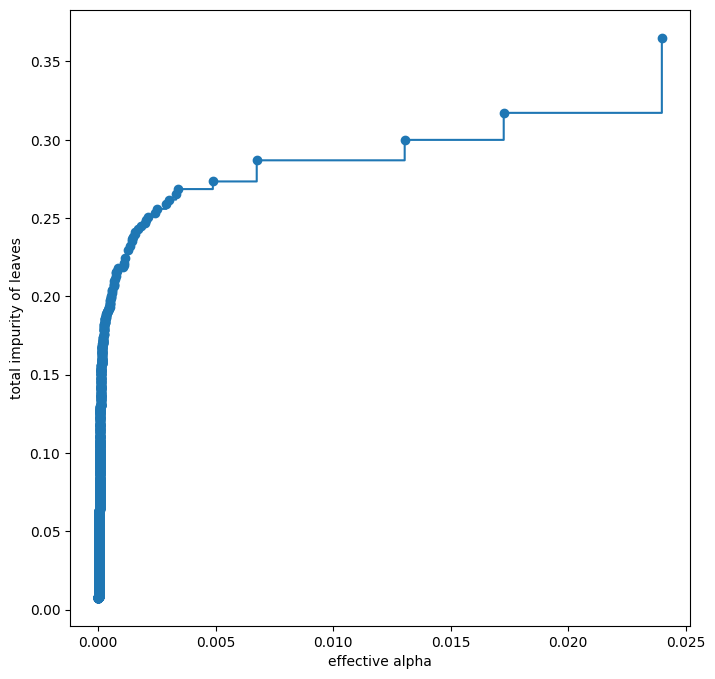

In [ ]:
# Let's plot this to visualise the pattern between our alphas and impurities:

plt.figure (figsize = (8,8))
plt.plot (ccp_alphas[:-1], impurities[:-1], marker = "o", drawstyle = "steps-post")
plt.xlabel ("effective alpha")
plt.ylabel ("total impurity of leaves")

plt.show()

- As we can see, as alpha goes up, so does the impurity, which is expected as we reduce the purity of the leaves as we remove nodes.

In [ ]:
# Now, lets move onto to listing out a tree for each alpha and then picking the best one from them:

clfs = []

for ccp_alpha in ccp_alphas:
  clf = DecisionTreeClassifier (random_state=1, ccp_alpha=ccp_alpha)
  clf.fit (x_train_dt, y_train_dt)
  clfs.append(clf)

# Now since the last tree has only one node, we remove that:

clfs = clfs[:-1]
ccp_alphas = ccp_alphas [:-1]

In [ ]:
# Next, let's find the Accuracy scores:

train_accuracy_scores = [clf.score (x_train_dt, y_train_dt) for clf in clfs]
test_accuracy_scores = [clf.score (x_test_dt, y_test_dt) for clf in clfs]

In [ ]:
# Now, let's find the model that corresponds to the best scores:

index_best_model_by_accuracy = np.argmax (test_accuracy_scores)
best_model_by_accuracy = clfs[index_best_model_by_accuracy]

print ("Accuracy of Decision Tree on training dataset: ", round (best_model_by_accuracy.score(x_train_dt, y_train_dt),2))
print ("Accuracy of Decision Tree on testing dataset: ", round (best_model_by_accuracy.score(x_test_dt, y_test_dt), 2))

Accuracy of Decision Tree on training dataset:  0.9
Accuracy of Decision Tree on testing dataset:  0.88


- The Accuracy of the best model (by Accuracy) gives us 0.90 and 0.88 in training and testing datasets respectively, which is really great since they are both high as well as close to one another.

- However, since Sensitivity is a more important metric over here, let's try to find the best model by Sensitivity as well.

In [ ]:
# Let's find the Sensitivities for our model from training and testing datasets:

sensitivity_training = []

for clf in clfs:
  pred_train_dt_postpruned = clf.predict(x_train_dt)
  values_training = recall_score (y_train_dt, pred_train_dt_postpruned)
  sensitivity_training.append (values_training)

sensitivity_testing = []

for clf in clfs:
  pred_test_dt_postpruned = clf.predict(x_test_dt)
  values_testing = recall_score (y_test_dt, pred_test_dt_postpruned)
  sensitivity_testing.append (values_testing)

In [ ]:
# Now let's find the model that corresponds to the best Sensitivity:

index_best_model_by_sensitivity = np.argmax (sensitivity_testing)
best_model_by_sensitivity = clfs[index_best_model_by_sensitivity]

print ("Sensitivity of Decision Tree on training dataset: ", round (recall_score(y_train_dt, pred_train_dt_postpruned), 2))
print ("Sensitivity of Decision Tree on testing dataset: ", round (recall_score(y_test_dt, pred_test_dt_postpruned), 2))

Sensitivity of Decision Tree on training dataset:  0.43
Sensitivity of Decision Tree on testing dataset:  0.44


- When we pick the best model by Sensitivity, we see that it infact even performs slightly better on the testing dataset.

- Hence, we can conclude that the best cost complexity pruned model based on Sensitivity is the best_model_by_sensitivity.

In [ ]:
# Let's also find the Accuracy scores that correspond to this model:

print ("Accuracy of Decision Tree on training dataset: ", round (best_model_by_sensitivity.score(x_train_dt, y_train_dt),2))
print ("Accuracy of Decision Tree on testing dataset: ", round (best_model_by_sensitivity.score(x_test_dt, y_test_dt), 2))

Accuracy of Decision Tree on training dataset:  0.96
Accuracy of Decision Tree on testing dataset:  0.88


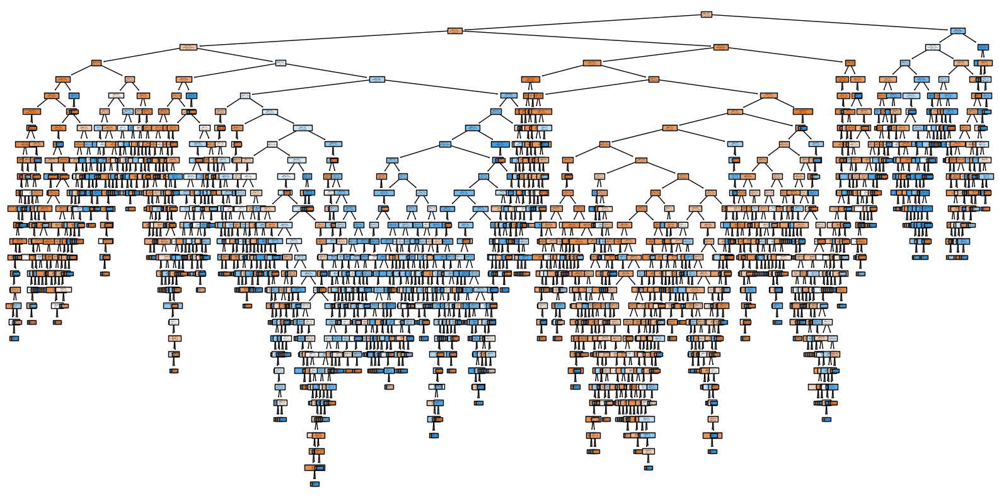

In [ ]:
# Let's quickly visualise this tree to get a sense for what it is like:

plt.figure(figsize=(20,10))
plot_tree(best_model_by_sensitivity, feature_names=x_train_dt.columns, class_names=True, filled=True)
plt.show()

- We can see that this tree is considerably more complex than the one we got using the pre-pruning approach. But nonetheless, this is the best tree we get from cost complexity pruning that optimises for Sensitivity.

## **Model Performance Comparison and Final Model Selection**

- We have 3 models at this point, one made using logistic regression, another made using a pre-pruning approach to decision tree classification, and the last made using a post-pruning approach to decision tree classfication.

- We need common performance metrics to compare these 3, and we will be looking at the metrics of Accuracy and Sensitivity on the testing dataset across all 3 models for this purpose.

In [ ]:
# Let's make a comparison table of the Accuracy and Sensitivity scores on the testing datasets across all 3 models:

# Since we've already picked the best models from within each approach, we've already established that their scores are similar between training and testing datasets on different metrics. At this point, since we're comparing across models, just comparing the test scores will do.

comparison_table = pd.DataFrame ({ "Model": ["Logistic Regression", "Pre-pruning", "Post-pruning"], "Accuracy": [0.79, 0.77, 0.88], "Sensitivity": [0.75, 0.77, 0.44]})
comparison_table

,Model,Accuracy,Sensitivity
0,Logistic Regression,0.79,0.75
1,Pre-pruning,0.77,0.77
2,Post-pruning,0.88,0.44


- We have previously noted that Sensitivity or Recall is more important of a metric in this context than Accuracy, due to the nature of the metric itself as well as the fact that in our problem, false negatives are more expensive than false positives. Hence, we will use Sensitivity as our primary metric in deciding which model to finalise.

- We see that the pre-pruning decision tree model has the best Sensitivity of all 3 models while also faring comparably on the Accuracy metric, unlike the other 2.

- We will therefore conclude to f**inalise the pre-pruning decision tree model** for predicting whether or not a customer will cancel their booking based on the attributes observed in their booking.

## **Actionable Insights and Recommendations**

- lead_time, avg_price_per_room, market_segment_type_Online, and arrival_date are the factors that play the most important role in determining the likelihood that a customer cancels their booking.

- Largely speaking, a longer lead time and higher price per room negetively impact the likelihood that someone might cancel. The business can allocate more resources to nudge people towards bookings and consider running offers to ease the barrier.

- The business can consider better understanding their online booking customer base to accomodate their approaches better.

- Loyalty programs might also be considered to reward and incentivise repeated visits, as the vast majority are first time visitors who are also more likely to cancel.

